## This code is for filtering the primary candidate list by using the target reaction mechanism key step and comparing it with literature examples. By doing so, we aim to identify candidates that are more likely to achieve the reaction by 'similarity' 

In [22]:
# Import primary candidate list for target reaction (Ni-catalyzed CO and ethylene alternating and nonalternating copolymerization)
# Extract from a table that contains the candidates
# Import known literature examples for target reaction (from directory)
# Obtain descriptor set from key mechanistic step of the target reaction (intermediate opt + spe calculation)
# Compare descriptor set of candidate list with literature example via chemical space map
# Identify those that are intuitive vs. nonintuitive, based by ranking distance of each
# candidate to the closest 'literature example' on the chemical space map

In [23]:
import pandas as pd
import os

# Set the path to the current directory
current_dir = os.getcwd()

spe_directory = os.path.join(os.getcwd(), "spe") 
complex_xyz_directory =  os.path.join(os.getcwd(), "complex_xyz") 

# File paths for CSV files
alt_file = os.path.join(current_dir, 'co_et_ni_alt_list.csv')
nonalt_file = os.path.join(current_dir, 'co_et_ni_nonalt_list.csv')

# Read CSV files into DataFrames
df_alt = pd.read_csv(alt_file)
df_nonalt = pd.read_csv(nonalt_file)

# Preview the first few rows
print("Alt list:")
print(df_alt.head())

print("\nNon-alt list:")
print(df_nonalt.head())


Alt list:
                 filename  lig_node         rxn_node ligand_name  \
0    ligand-11-c-n-7-int1        11  CO_alt-ethylene       c-n-7   
1   ligand-124-c-o-3-int1       124  CO_alt-ethylene       c-o-3   
2  ligand-126-p-p-25-int1       126  CO_alt-ethylene      p-p-25   
3  ligand-127-p-p-26-int1       127  CO_alt-ethylene      p-p-26   
4    ligand-13-p-p-5-int1        13  CO_alt-ethylene       p-p-5   

  candidate_literature  ni_atom_label  ligand_atom_1_label  \
0            candidate             50                    1   
1            candidate            108                    1   
2            candidate             57                    6   
3            candidate             69                    1   
4            candidate             83                    6   

   ligand_atom_2_label                                atoms_to_exclude  
0                   16              [5,6,7,51,52,53,58,59,54,55,56,57]  
1                   35  [32,33,34,109,110,111,116,112,113,114,

In [24]:
df_nonalt

,filename,lig_node,rxn_node,ligand_name,candidate_literature,ni_atom_label,ligand_atom_1_label,ligand_atom_2_label,atoms_to_exclude
0,ligand-81-p-o-7-int1,81,CO_nonalt-ethylene,p-o-7,literature,55,1,30,"[33,34,35,56,57,58,63,64,59,60,61,62]"
1,ligand-84-p-o-10-int1,84,CO_nonalt-ethylene,p-o-10,candidate,66,1,28,"[30,31,32,67,68,75,73,74,69,70,71,72]"
2,ligand-85-p-o-11-int1,85,CO_nonalt-ethylene,p-o-11,candidate,74,1,5,"[16,17,18,65,66,67,72,73,68,70,71,69]"
3,ligand-86-p-o-12-int1,86,CO_nonalt-ethylene,p-o-12,candidate,69,1,5,"[15,16,17,70,71,72,77,78,73,74,75,76]"
4,ligand-87-p-o-13-int1,87,CO_nonalt-ethylene,p-o-13,candidate,57,1,5,"[16,17,18,48,49,50,51,52,53,54,55,56]"
5,ligand-88-p-o-14-int1,88,CO_nonalt-ethylene,p-o-14,candidate,71,1,5,"[15,16,17,72,73,74,79,80,75,76,77,78]"
6,ligand-90-p-o-16-int1,90,CO_nonalt-ethylene,p-o-16,candidate,58,1,2,"[55,56,57,59,61,60,66,67,62,63,64,65]"
7,ligand-92-p-o-18-int1,92,CO_nonalt-ethylene,p-o-18,candidate,52,1,5,"[15,16,17,53,54,55,60,61,56,57,58,59]"
8,ligand-96-p-o-22-int1,96,CO_nonalt-ethylene,p-o-22,candidate,71,1,5,"[15,16,17,72,73,74,79,80,75,77,76,78]"
9,ligand-97-p-o-23-int1,97,CO_nonalt-ethylene,p-o-23,candidate,77,1,5,"[15,16,17,78,79,80,85,86,81,82,83,84]"


In [25]:
import os

# Define paths
base_dir = os.getcwd()
opt_dir = os.path.join(base_dir, 'opt')
spe_dir = os.path.join(base_dir, 'spe')

def extract_base_name(filename, suffix):
    """Removes the suffix (-opt or -spe) and .out extension."""
    if filename.endswith('.out') and suffix in filename:
        return filename.replace(f'-{suffix}.out', '')
    return None

# Get sets of base names from both directories
opt_basenames = {
    extract_base_name(f, 'opt') for f in os.listdir(opt_dir)
    if extract_base_name(f, 'opt') is not None
}

spe_basenames = {
    extract_base_name(f, 'spe') for f in os.listdir(spe_dir)
    if extract_base_name(f, 'spe') is not None
}

# Compare sets
missing_in_spe = opt_basenames - spe_basenames
missing_in_opt = spe_basenames - opt_basenames

# Report results
print("Files in opt but missing in spe:")
for name in sorted(missing_in_spe):
    print(f"{name}-spe.out")

print("\nFiles in spe but missing in opt:")
for name in sorted(missing_in_opt):
    print(f"{name}-opt.out")


Files in opt but missing in spe:

Files in spe but missing in opt:


# Obtain atom_labels

In [26]:
import os
import pandas as pd
import numpy as np
import re
from pathlib import Path
import ast

# === USER INPUTS ===
opt_directory = os.path.join(os.getcwd(), "opt") 
bond_threshold = 1.93  # bond cutoff distance in Å

# Load your dataframes here
label_dfs = [df_alt, df_nonalt]
df_names = ['alt', 'nonalt']  # To identify which output belongs to which source

# === FUNCTION to parse XYZ block ===
def extract_xyz_block(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()

    natoms = 0
    for line in lines:
        if "NAtoms=" in line:
            natoms = int(re.findall(r'\d+', line)[0])
            break

    xyz_lines = []
    for i, line in enumerate(lines):
        if "X           Y           Z" in line:
            xyz_lines = lines[i+1 : i+1+natoms]
            break

    data = []
    for line in xyz_lines:
        parts = re.findall(r'-?\d+\.\d+|-?\d+', line)
        if len(parts) >= 6:
            atom_index = int(parts[0])
            x, y, z = map(float, parts[3:6])
            data.append((atom_index, x, y, z))

    return pd.DataFrame(data, columns=["Index", "X", "Y", "Z"])

# === FUNCTION to find bonded neighbors ===
def neighbors(center_idx, avoid_set, coords_dict):
    center = np.array([coords_dict[center_idx]["X"], coords_dict[center_idx]["Y"], coords_dict[center_idx]["Z"]])
    result = []
    for idx, pos in coords_dict.items():
        if idx == center_idx or idx in avoid_set:
            continue
        dist = np.linalg.norm(center - np.array([pos["X"], pos["Y"], pos["Z"]]))
        if 0.1 < dist < bond_threshold:
            result.append(idx)
    return result

# === Initialize one output dict per label_df ===
output_data = {
    'alt': [],
    'nonalt': []
}

# === MAIN LOOP ===
for subdir, dirs, files in os.walk(opt_directory):
    for file in files:
        if file.endswith("-opt.out"):
            filename = Path(file).stem.replace("-opt", "")
            # print(filename)
            full_path = os.path.join(subdir, file)
            print(f"Processing: {filename}")

            matched_row = None
            matched_group = None

            # Try to match ligand_name from either df_alt or df_nonalt
            for df_name, label_df in zip(df_names, label_dfs):
                # print(label_df.columns.tolist()
                matches = label_df[label_df["filename"] == filename]
                if not matches.empty:
                    matched_row = matches.iloc[0]
                    matched_group = df_name
                    break


            if matched_row is None:
                print(f"Skipping {filename} — no match found")
                continue

            # Extract labeled atoms
            metal = int(matched_row["ni_atom_label"])
            atom_a = int(matched_row["ligand_atom_1_label"])
            # print('Atom_A: ', atom_a)
            atom_b = int(matched_row["ligand_atom_2_label"])
            # print('Atom_B: ', atom_b)
            atoms_to_exclude =  ast.literal_eval(matched_row["atoms_to_exclude"])
            
            # Get coordinates
            xyz_df = extract_xyz_block(full_path)
            coords = xyz_df.set_index("Index")[["X", "Y", "Z"]].to_dict("index")

            # Distance 2
            dist2_a = neighbors(atom_a, avoid_set={metal}, coords_dict=coords)
            dist2_b = neighbors(atom_b, avoid_set={metal}, coords_dict=coords)
            dist2 = sorted(set(dist2_a + dist2_b) - {metal})

            # Distance 3
            dist3_a = []
            for atom in dist2_a:
                dist3_a += neighbors(atom, avoid_set={atom_a, metal} | set(dist2_a), coords_dict=coords)
            dist3_a = sorted(set(dist3_a) - {metal})

            dist3_b = []
            for atom in dist2_b:
                dist3_b += neighbors(atom, avoid_set={atom_b, metal} | set(dist2_b), coords_dict=coords)
            dist3_b = sorted(set(dist3_b) - {metal})

            dist3 = sorted(set(dist3_a + dist3_b) - {metal})

            # Distance 4
            dist4_a = []
            for atom in dist3_a:
                dist4_a += neighbors(atom, avoid_set={atom_a, metal} | set(dist2_a + dist3_a), coords_dict=coords)
            dist4_a = sorted(set(dist4_a) - {metal})

            dist4_b = []
            for atom in dist3_b:
                dist4_b += neighbors(atom, avoid_set={atom_b, metal} | set(dist2_b + dist3_b), coords_dict=coords)
            dist4_b = sorted(set(dist4_b) - {metal})

            dist4 = sorted(set(dist4_a + dist4_b) - {metal})
            
            # Collect record
            output_data[matched_group].append({
                "Filename": filename,
                "Ni_atom_label": metal,
                "Ligand_atom_1_label": atom_a,
                "Ligand_atom_2_label": atom_b,
                "Atoms_distance_2": dist2,
                "Atoms_distance_3": dist3,
                "Atoms_distance_4": dist4,
                "Atoms_distance_2_a": dist2_a,
                "Atoms_distance_3_a": dist3_a,
                "Atoms_distance_4_a": dist4_a,
                "Atoms_distance_2_b": dist2_b,
                "Atoms_distance_3_b": dist3_b,
                "Atoms_distance_4_b": dist4_b,
                "Atoms_to_exclude" : atoms_to_exclude,
            })

# === WRITE OUTPUT FILES ===
for group_name, records in output_data.items():
    out_df = pd.DataFrame(records)
    csv_name = f"{group_name}_nickel_atom_distance_labels.csv"
    out_df.to_csv(csv_name, index=False)
    print(f"✅ Saved: {csv_name}")


Processing: ligand-100-p-o-26-int1
Processing: ligand-11-c-n-7-int1
Processing: ligand-124-c-o-3-int1
Processing: ligand-126-p-p-25-int1
Processing: ligand-127-p-p-26-int1
Processing: ligand-13-p-p-5-int1
Processing: ligand-14-p-c-1-int1
Processing: ligand-15-p-c-2-int1
Processing: ligand-16-p-c-3-int1
Processing: ligand-18-p-c-5-int1
Processing: ligand-183-n-o-34-int1
Processing: ligand-186-p-o-53-int1
Processing: ligand-187-p-o-54-int1
Processing: ligand-19-p-c-6-int1
Processing: ligand-2-p-p-1-int1
Processing: ligand-21-p-c-8-int1
Processing: ligand-22-p-c-9-int1
Processing: ligand-242-n-o-79-int1
Processing: ligand-243-p-o-63-int1
Processing: ligand-244-p-o-64-int1
Processing: ligand-245-p-o-65-int1
Processing: ligand-246-c-n-8-int1
Processing: ligand-248-c-o-4-int1
Processing: ligand-251-p-o-66-int1
Processing: ligand-252-p-o-67-int1
Processing: ligand-255-p-o-70-int1
Processing: ligand-260-c-o-10-int1
Processing: ligand-266-p-o-75-int1
Processing: ligand-267-p-o-76-int1
Processin

In [27]:
xyz_match = ['X           Y           Z']
LUMO_match = ['Alpha virt. eigenvalues']
HOMO_match = ['Alpha  occ. eigenvalues']
nbo_match = ['Natural Population Analysis']
mulliken_match = ['Mulliken charges:']

missing_nbo_spe_calc =[]
missing_mulliken_spe_calc = []
# Initiate list for gathering descriptor values
name_list = []
metal_atom_list = []
ligand_atom_a_list = []
ligand_atom_b_list = []
metal_ligand_distance_1_list = []
metal_ligand_distance_2_list = []
bite_angle_list = []
lumo_list = []
homo_list = []
homo_lumo_list = []
nbo_ni_list = []
nbo_a_list = []
nbo_b_list = []
nbo_a_b_list = []
nbo_a_b_avg_list = []
nbo_dist_2_avg_list = []
nbo_dist_3_avg_list = []
nbo_dist_4_avg_list = []
nbo_dist_2_min_list = []
nbo_dist_3_min_list = []
nbo_dist_4_min_list = []
nbo_dist_2_max_list = []
nbo_dist_3_max_list = []
nbo_dist_4_max_list = []
nbo_dist_2_a_avg_list = []
nbo_dist_3_a_avg_list = []
nbo_dist_4_a_avg_list = []
nbo_dist_2_b_avg_list = []
nbo_dist_3_b_avg_list = []
nbo_dist_4_b_avg_list = []
nbo_dist_2_a_b_avg_diff_list = []
nbo_dist_3_a_b_avg_diff_list = []
nbo_dist_4_a_b_avg_diff_list = []
nbo_dist_2_a_min_list = []
nbo_dist_3_a_min_list = []
nbo_dist_4_a_min_list = []
nbo_dist_2_a_max_list = []
nbo_dist_3_a_max_list = []
nbo_dist_4_a_max_list = []
nbo_dist_2_b_min_list = []
nbo_dist_3_b_min_list = []
nbo_dist_4_b_min_list = []
nbo_dist_2_b_max_list = []
nbo_dist_3_b_max_list = []
nbo_dist_4_b_max_list = []

nbo_metal_donor_diff_list = []
nbo_metal_a_diff_list = []
nbo_metal_b_diff_list = []
nbo_2_1_avg_diff_list = []
nbo_3_2_avg_diff_list = []
nbo_4_3_avg_diff_list = []
nbo_2_1_a_avg_diff_list = []
nbo_3_2_a_avg_diff_list = []
nbo_4_3_a_avg_diff_list = []
nbo_2_1_b_avg_diff_list = []
nbo_3_2_b_avg_diff_list = []
nbo_4_3_b_avg_diff_list = []
 

mulliken_ni_list = []
mulliken_a_list = []
mulliken_b_list = []
mulliken_a_b_list = []
mulliken_dist_2_avg_list = []
mulliken_dist_3_avg_list = []
mulliken_dist_4_avg_list = []


In [28]:
import pandas as pd
import ast
import math

# Load your label files
new_df_alt = pd.read_csv("alt_nickel_atom_distance_labels.csv")
new_df_nonalt = pd.read_csv("nonalt_nickel_atom_distance_labels.csv")
label_dfs = [new_df_alt, new_df_nonalt]
df_names = ["alt", "nonalt"]


# Read in .out file
index_count = 0
for subdir,dirs,files in os.walk(spe_directory):                  # Loop over each directory, subdirectory and files
    for file in files:                                      # Loop over each file
        if any([file.endswith('-spe.out')]):                    # If file is a .out file
            filename = os.path.join(subdir, file)       # Return path to file
            name = Path(filename).stem           # Extract filename from the end of path and return as a string
            name = name.replace('-spe','')     #Remove -opt in string to get just the name of ligand 'ni-x-x-x'
            name_list.append(name)
            print(name)

            mylines = []

            with open (filename, 'rt') as myfile:       # Open .out for reading text
                # myfile = myfile.read()                # Read the entire file to a string
                for myline in myfile:                    # For each line, stored as myline,
                    mylines.append(myline)               # add its contents to mylines list.

                    
                for line in mylines:
                    if 'NAtoms' in line:
                        number_list = re.findall('-?\d*\.?\d+',line)            # get number of atoms
                        natoms = int(number_list[0])     

                # Identify row in atom_label_df that matches the name
                matching_row = None
                for label_df in label_dfs:
                    row = label_df[label_df['Filename'] == name]
                    if not row.empty:
                        matching_row = row
                        break
                
                if matching_row is None:
                    print(f"Skipping {name} — no matching row found")
                    continue
                
                # Reset index so you can access row data by `.loc[0]`
                matching_row = matching_row.reset_index(drop=True)
                
                # Assign atom labels based on dataframe 
                # print(index_count)
                ni_atom = matching_row.loc[0]['Ni_atom_label']
                print(ni_atom)
                ligand_atom_1 = matching_row.loc[0]['Ligand_atom_1_label']
                ligand_atom_2 = matching_row.loc[0]['Ligand_atom_2_label']
                atoms_distance_2 = ast.literal_eval(matching_row.loc[0]['Atoms_distance_2'])
                atoms_distance_3 = ast.literal_eval(matching_row.loc[0]['Atoms_distance_3'])
                atoms_distance_4 = ast.literal_eval(matching_row.loc[0]['Atoms_distance_4'])
                atoms_distance_2_a = ast.literal_eval(matching_row.loc[0]['Atoms_distance_2_a'])
                atoms_distance_3_a = ast.literal_eval(matching_row.loc[0]['Atoms_distance_3_a'])                
                atoms_distance_4_a = ast.literal_eval(matching_row.loc[0]['Atoms_distance_4_a'])                
                atoms_distance_2_b = ast.literal_eval(matching_row.loc[0]['Atoms_distance_2_b'])
                atoms_distance_3_b = ast.literal_eval(matching_row.loc[0]['Atoms_distance_3_b'])                
                atoms_distance_4_b = ast.literal_eval(matching_row.loc[0]['Atoms_distance_4_b'])                 
                # atom_label_shortest_path = ast.literal_eval(matching_row.loc[index_count]['Atom label shortest paths'])    

 
                for line in mylines:
                    for phrase in xyz_match:                                # iterate through each phrases
                        if phrase in line:                                          # check if phrase is in line

                                                                                    # For loop for generating the XYZ coordinates
                            count = 0
                            xyz = []
                            line_number = mylines.index(line) + 2
                            while count < natoms:
                                count = count + 1
                                xyz.append(mylines[line_number])
                                line_number = line_number + 1


                x_coord = []
                y_coord = []
                z_coord = []
                atom_symbol =[]
                element = {"1":'H', "5":"B", "6":"C", "7": "N", "8":"O", "9":"F", "14": "Si", "15":"P", "16":"S", "17":"Cl", "26":"Fe", "28":"Ni","35":"Br", "46":"Pd"}

                # Generate XYZ file in .txt form, then find xyz coordinates for metal, atom_a and atom_b
                for line in xyz:
                    number_list = re.findall('-?\d*\.?\d+',line)
                    atom_number = int(number_list[0])
                    element_number = int(number_list[1])
                    atom_x = float(number_list[3])
                    atom_y = float(number_list[4])
                    atom_z = float(number_list[5])

                    # Make xyz coord into .txt file for percent buried volume
                    x_coord.append(atom_x)
                    y_coord.append(atom_y)
                    z_coord.append(atom_z)
                    atom_symbol.append(element[str(element_number)])
                    name_xyz = name + '_xyz.txt'            

    #                     xyz_df.to_csv(name_xyz, header=False, index=False, sep = " ")

                    # Identify metal, atom_a and atom_b numbers and obtain their respective x,y,z coords
                    if atom_number == ni_atom:
                        metal_x = atom_x
                        metal_y = atom_y
                        metal_z = atom_z
                        if element_number != 28:
                            print('Wrong metal atom number assignment ',filename) # Checking if metal atom was assigned correctly
                    elif atom_number == ligand_atom_1:
                        a_x = atom_x
                        a_y = atom_y
                        a_z = atom_z
                    elif atom_number == ligand_atom_2:
                        b_x = atom_x
                        b_y = atom_y
                        b_z = atom_z

                data = {
                    'Atom': atom_symbol,
                    'X': x_coord,
                    'Y': y_coord,
                    'Z': z_coord
                }

                xyz_df = pd.DataFrame(data)                 


                # print(type(matching_row))

                # Find HOMO - LUMO energy gap in SPE file

                LUMO = []
                for phrase in LUMO_match:
                    for line in mylines:
                        if phrase in line:
                            LUMO.append(line)
                number_list = re.findall('-?\d*\.?\d+',LUMO[0])            # get value from line containing LUMO
                LUMO_energy = float(number_list[0])                         # get first value from the line, which represents the LUMO

                HOMO = []
                for phrase in HOMO_match:
                    for line in mylines:
                        if phrase in line:
                            HOMO.append(line)
                number_list = re.findall('-?\d*\.?\d+',HOMO[-1])            # get value from line containing LUMO
                HOMO_energy = float(number_list[-1])                        # get lsat value from line, which represents HOMO

                HOMO_LUMO = round(LUMO_energy - HOMO_energy,4)    
                print('LUMO: ', LUMO_energy)
                print('HOMO: ', HOMO_energy)
                print('HOMO_LUMO: ', HOMO_LUMO)


                # Find NBO charge 

                #Obtain indexes for calculating NBO charge of different atom distances

                for phrase in nbo_match:                                       # iterate through each phrases
                    nbo_match_count = 0
                    for line in mylines:
                        if phrase in line:                                          # check if phrase is in line
                            nbo_match_count = nbo_match_count + 1
                            count = 0
                            nbo_xyz = []
                            line_number = mylines.index(line) + 6
                            while count < natoms:
                                count = count + 1
                                nbo_xyz.append(mylines[line_number])
                                line_number = line_number + 1

                            with open('nbo.txt', 'w') as filehandle:                   # Save nbo_xyz  into a txt file
                                for listitem in nbo_xyz:
                                    filehandle.write(listitem)
                    
                    

                # Extract NBO charge for metal, atom A and atom B, atom at distance 2,3,4
                if nbo_match_count == 0:
                    print('No NBO Charge calculation for ', name)
                    missing_nbo_spe_calc.append(name)
         
                    metal_nbo = 'Missing'
                    a_nbo = 'Missing'
                    nbo_difference = 'Missing'
                    nbo_a_b_avg = 'Missing'
                    nbo_distance_2_avg = 'Missing'
                    nbo_distance_3_avg = 'Missing'
                    nbo_distance_4_avg = 'Missing'
                    nbo_dist_2_a_avg = 'Missing'                  
                    nbo_dist_3_a_avg = 'Missing'  
                    nbo_dist_4_a_avg ='Missing'                   
                    nbo_dist_2_b_avg = 'Missing'           
                    nbo_dist_3_b_avg = 'Missing'
                    nbo_dist_4_b_avg = 'Missing'
                    
                    nbo_dist_2_min = 'Missing'
                    nbo_dist_3_min = 'Missing'               
                    nbo_dist_4_min ='Missing'
                    nbo_dist_2_max = 'Missing'
                    nbo_dist_3_max = 'Missing'                 
                    nbo_dist_4_max = 'Missing' 
                    
                    nbo_dist_2_a_b_avg_diff = 'Missing'             
                    nbo_dist_3_a_b_avg_diff = 'Missing'           
                    nbo_dist_4_a_b_avg_diff = 'Missing'
                    
                    nbo_dist_2_a_min = 'Missing'
                    nbo_dist_3_a_min = 'Missing'              
                    nbo_dist_4_a_min = 'Missing'                   
                    nbo_dist_2_b_min = 'Missing'
                    nbo_dist_3_b_min = 'Missing'              
                    nbo_dist_4_b_min = 'Missing'   
                    nbo_dist_2_a_max = 'Missing'
                    nbo_dist_3_a_max = 'Missing'         
                    nbo_dist_4_a_max = 'Missing'         
                    nbo_dist_2_b_max = 'Missing'
                    nbo_dist_3_b_max = 'Missing'           
                    nbo_dist_4_b_max = 'Missing'  
                    
                    nbo_metal_donor_diff = 'Missing'  
                    nbo_metal_a_diff ='Missing'                               
                    nbo_metal_b_diff = 'Missing'  
                    nbo_2_1_avg_diff = 'Missing'  
                    nbo_3_2_avg_diff = 'Missing'  
                    nbo_4_3_avg_diff = 'Missing'  
                    nbo_2_1_a_avg_diff = 'Missing'  
                    nbo_3_2_a_avg_diff = 'Missing'  
                    nbo_4_3_a_avg_diff = 'Missing'  
                    nbo_2_1_b_avg_diff = 'Missing'  
                    nbo_3_2_b_avg_diff = 'Missing'  
                    nbo_4_3_b_avg_diff = 'Missing'  
                          
                    
                elif nbo_match_count > 0:

                    nbo_distance_2 = []
                    nbo_distance_3 = []
                    nbo_distance_4 = []
                    nbo_distance_2_a = []
                    nbo_distance_3_a = []
                    nbo_distance_4_a = []   
                    nbo_distance_2_b = []
                    nbo_distance_3_b = []
                    nbo_distance_4_b = []   
                    atom_number_check_3_a = []
                    atom_number_check_4_a = []
                    atom_number_check_3_b = []
                    atom_number_check_4_b = []                    
                    

                    for line in nbo_xyz:
                        number_list = re.findall('-?\d*\.?\d+',line)
                        atom_number = int(number_list[0])

                        if atom_number == ni_atom:
                            metal_nbo = float(number_list[1])
                            print('Ni_nbo: ', metal_nbo)

                        elif atom_number == ligand_atom_1:
                            a_nbo = float(number_list[1])
                            # print('Ligand atom A nbo: ', a_nbo)

                        elif atom_number == ligand_atom_2:
                            b_nbo = float(number_list[1]) 
                            # print('Ligand atom B nbo: ', b_nbo)

                        elif atom_number in atoms_distance_2:
                            nbo_distance_2.append(float(number_list[1]))

                        elif atom_number in atoms_distance_3:
                            nbo_distance_3.append(float(number_list[1]))                

                        elif atom_number in atoms_distance_4:
                            nbo_distance_4.append(float(number_list[1]))
                        
                        if atom_number in atoms_distance_2_a:
                            nbo_distance_2_a.append(float(number_list[1]))

                        elif atom_number in atoms_distance_3_a:
                            nbo_distance_3_a.append(float(number_list[1]))
                            atom_number_check_3_a.append(atom_number)
                            
                        elif atom_number in atoms_distance_4_a:
                            nbo_distance_4_a.append(float(number_list[1]))
                            atom_number_check_4_a.append(atom_number)
                            
                        if atom_number in atoms_distance_2_b:
                            nbo_distance_2_b.append(float(number_list[1]))

                        elif atom_number in atoms_distance_3_b:
                            nbo_distance_3_b.append(float(number_list[1]))
                            atom_number_check_3_b.append(atom_number)
                            
                        elif atom_number in atoms_distance_4_b:
                            nbo_distance_4_b.append(float(number_list[1]))
                            atom_number_check_4_b.append(atom_number)
                                                   
                    nbo_a_b_avg = round((a_nbo+b_nbo)/ 2, 4)
                    nbo_distance_2_avg = round(sum(nbo_distance_2) / len(nbo_distance_2), 4)
                    nbo_distance_3_avg = round(sum(nbo_distance_3) / len(nbo_distance_3),4)                      
                    nbo_a_b_avg = round((a_nbo+b_nbo)/ 2, 4)
                    nbo_distance_2_avg = round(sum(nbo_distance_2) / len(nbo_distance_2), 4)
                    nbo_distance_3_avg = round(sum(nbo_distance_3) / len(nbo_distance_3),4)                       
                    nbo_dist_2_a_avg = round(sum(nbo_distance_2_a) / len(nbo_distance_2_a),4)                    
                    nbo_dist_3_a_avg = round(sum(nbo_distance_3_a) / len(nbo_distance_3_a),4)                                         
                    nbo_dist_2_b_avg = round(sum(nbo_distance_2_b) / len(nbo_distance_2_b),4)                    
                    nbo_dist_3_b_avg = round(sum(nbo_distance_3_b) / len(nbo_distance_3_b),4)     
                    nbo_dist_2_min = min(nbo_distance_2)
                    nbo_dist_3_min = min(nbo_distance_3)                                            
                    nbo_dist_2_max = max(nbo_distance_2)
                    nbo_dist_3_max = max(nbo_distance_3)                    
                    nbo_dist_2_a_b_avg_diff = round(abs(nbo_dist_2_a_avg-nbo_dist_2_b_avg),4)                  
                    nbo_dist_3_a_b_avg_diff = round(abs(nbo_dist_3_a_avg-nbo_dist_3_b_avg),4)                        
                    nbo_dist_2_a_min = min(nbo_distance_2_a)
                    nbo_dist_3_a_min = min(nbo_distance_3_a)                                                        
                    nbo_dist_2_b_min = min(nbo_distance_2_b)
                    nbo_dist_3_b_min = min(nbo_distance_3_b)                                                
                    nbo_dist_2_a_max = max(nbo_distance_2_a)
                    nbo_dist_3_a_max = max(nbo_distance_3_a)                                                      
                    nbo_dist_2_b_max = max(nbo_distance_2_b)
                    nbo_dist_3_b_max = max(nbo_distance_3_b)                    
                                            


                    # print('Average NBO for atom at distance 2: ', nbo_distance_2_avg)
                    # print('Average NBO for atom at distance 3: ', nbo_distance_3_avg)

                    # print('Average NBO for atom at distance 2 from A:', nbo_dist_2_a_avg)
                    # print('Average NBO for atom at distance 3 from A:', nbo_dist_3_a_avg)                    

                    # print('Average NBO for atom at distance 2 from B:', nbo_dist_2_b_avg)
                    # print('Average NBO for atom at distance 3 from B:', nbo_dist_3_b_avg)                    
             
                    # print('Average NBO diff for atom at distance 2: ', nbo_dist_2_a_b_avg_diff)
                    # print('Average NBO diff for atom at distance 3: ', nbo_dist_3_a_b_avg_diff)
  


                    # print('Min NBO for atom at distance 2', nbo_dist_2_min)
                    # print('Min NBO for atom at distance 3', nbo_dist_3_min)                    
              
                    # print('Max NBO for atom at distance 2', nbo_dist_2_max)
                    # print('Max NBO for atom at distance 3', nbo_dist_3_max)                    
                                    
                    # print('Min NBO for atom at distance 2 from A:', nbo_dist_2_a_min)                    
                    # print('Min NBO for atom at distance 3 from A:', nbo_dist_3_a_min)                       
                
                    # print('Min NBO for atom at distance 2 from B:', nbo_dist_2_b_min)                    
                    # print('Min NBO for atom at distance 3 from B:', nbo_dist_3_b_min)                       
                                    
                    # print('Max NBO for atom at distance 2 from A:', nbo_dist_2_a_max)                    
                    # print('Max NBO for atom at distance 3 from A:', nbo_dist_3_a_max)                       
                  
                    # print('Max NBO for atom at distance 2 from B:', nbo_dist_2_b_max)                    
                    # print('Max NBO for atom at distance 3 from B:', nbo_dist_3_b_max)                       
                 

                    # print('Atom 3a check: ', atom_number_check_3_a)
                    # print('Atom 4a check: ', atom_number_check_4_a)                    
                    # print('Atom 3b check: ', atom_number_check_3_b)
                    # print('Atom 4b check: ', atom_number_check_4_b)     

                    nbo_difference = round(abs(a_nbo - b_nbo),4)
                    # print('NBO_diff: ', nbo_difference)

                    #Calculate difference in nbo between each distance
                    nbo_metal_donor_diff = abs(metal_nbo - nbo_a_b_avg)
                    nbo_metal_a_diff = abs(metal_nbo - a_nbo)
                    nbo_metal_b_diff = abs(metal_nbo - b_nbo)
                    nbo_2_1_avg_diff = abs(nbo_distance_2_avg - nbo_a_b_avg)
                    nbo_3_2_avg_diff = abs(nbo_distance_3_avg - nbo_distance_2_avg)       
                    nbo_2_1_a_avg_diff = abs(nbo_dist_2_a_avg - a_nbo)
                    nbo_3_2_a_avg_diff = abs(nbo_dist_3_a_avg - nbo_dist_2_a_avg)
                    nbo_2_1_b_avg_diff = abs(nbo_dist_2_b_avg - b_nbo)
                    nbo_3_2_b_avg_diff = abs(nbo_dist_3_b_avg - nbo_dist_2_b_avg)
       
                    # print('Average NBO metal donor atom diff:',nbo_metal_donor_diff)
                    # print('Difference Metal and Atom A', nbo_metal_a_diff)
                    # print('Difference Metal and Atom B', nbo_metal_b_diff)                    
                    # print('Average NBO distance 2 vs 1 diff:',nbo_2_1_avg_diff)                    
                    # print('Average NBO distance 3 vs 2 diff:',nbo_3_2_avg_diff)                        
                    # print('Average NBO distance 2 vs 1 from a diff:',nbo_2_1_a_avg_diff)                    
                    # print('Average NBO distance 3 vs 2 from a diff:',nbo_3_2_a_avg_diff)                                     
                    # print('Average NBO distance 2 vs 1 from b diff:',nbo_2_1_b_avg_diff)                    
                    # print('Average NBO distance 3 vs 2 from b diff:',nbo_3_2_b_avg_diff)                        

                    if len(nbo_distance_4) == 0:
                        print('Ligand has no more than 3 bond distances')
                        nbo_distance_4_avg = None
                        nbo_dist_4_a_avg = None
                        nbo_dist_4_b_avg = None        
                        nbo_dist_4_min = None
                        nbo_dist_4_max = None
                        nbo_dist_4_a_b_avg_diff = None
                        nbo_dist_4_a_min = None
                        nbo_dist_4_a_max = None
                        nbo_dist_4_b_min = None
                        nbo_dist_4_b_max = None
                        nbo_4_3_avg_diff = None
                        nbo_4_3_a_avg_diff = None
                        nbo_4_3_b_avg_diff = None

                    else:
                        nbo_distance_4_avg = round(sum(nbo_distance_4) / len(nbo_distance_4),4)
                        nbo_dist_4_a_avg = round(sum(nbo_distance_4_a) / len(nbo_distance_4_a),4)    
                        nbo_dist_4_b_avg = round(sum(nbo_distance_4_b) / len(nbo_distance_4_b),4)   
                        nbo_dist_4_min = min(nbo_distance_4)  
                        nbo_dist_4_max = max(nbo_distance_4)   
                        nbo_dist_4_a_b_avg_diff = round(abs(nbo_dist_4_a_avg-nbo_dist_4_b_avg),4)       
                        nbo_dist_4_a_min = min(nbo_distance_4_a)        
                        nbo_dist_4_b_min = min(nbo_distance_4_b)      
                        nbo_dist_4_a_max = max(nbo_distance_4_a)        
                        nbo_dist_4_b_max = max(nbo_distance_4_b)    
                        nbo_4_3_avg_diff = abs(nbo_distance_4_avg - nbo_distance_3_avg)                    
                        nbo_4_3_a_avg_diff = abs(nbo_dist_4_a_avg - nbo_dist_3_a_avg)  
                        nbo_4_3_b_avg_diff = abs(nbo_dist_4_b_avg - nbo_dist_3_b_avg)       


                        # print('Average NBO for atom at distance 4: ', nbo_distance_4_avg)
                        # print('Average NBO for atom at distance 4 from A:', nbo_dist_4_a_avg)
                        # print('Average NBO for atom at distance 4 from B:', nbo_dist_4_b_avg)   
                        # print('Min NBO for atom at distance 4', nbo_dist_4_min)                  
                        # print('Max NBO for atom at distance 4', nbo_dist_4_max)                          
                        # print('Average NBO diff for atom at distance 4: ', nbo_dist_4_a_b_avg_diff)  
                        # print('Min NBO for atom at distance 4 from A:', nbo_dist_4_a_min)   
                        # print('Min NBO for atom at distance 4 from B:', nbo_dist_4_b_min) 
                        # print('Max NBO for atom at distance 4 from A:', nbo_dist_4_a_max) 
                        # print('Max NBO for atom at distance 4 from B:', nbo_dist_4_b_max)                        
                        # print('Average NBO distance 4 vs 3 diff:',nbo_4_3_avg_diff)    
                        # print('Average NBO distance 4 vs 3 from a diff:',nbo_4_3_a_avg_diff)
                        # print('Average NBO distance 4 vs 3 from b diff:',nbo_4_3_b_avg_diff) 


                
                #Find Mulliken charge
                for phrase in mulliken_match:                                       # iterate through each phrases
                    mulliken_match_count = 0
                    for line in mylines:
                        if phrase in line:                                          # check if phrase is in line
                            mulliken_match_count = mulliken_match_count + 1

                            count = 0
                            mulliken_xyz = []
                            line_number = mylines.index(line) + 2
                            while count < natoms:
                                count = count + 1
                                mulliken_xyz.append(mylines[line_number])
                                line_number = line_number + 1

                            with open('mulliken.txt', 'w') as filehandle:                   # Save nbo_xyz  into a txt file
                                for listitem in mulliken_xyz:
                                    filehandle.write(listitem)            

                    
                if mulliken_match_count == 0:
                    print('No Mulliken Charge calculation for ', name)
                    missing_mulliken_spe_calc.append(name)

                    metal_mulliken = None
                    a_mulliken = None
                    b_mulliken = None
                    mulliken_difference = None
                    mulliken_distance_2_avg = None
                    mulliken_distance_3_avg = None
                    mulliken_distance_4_avg = None


                elif mulliken_match_count > 0:
                    # Extract mulliken charge for metal, atom A and atom B
                    mulliken_distance_2 = []
                    mulliken_distance_3 = []
                    mulliken_distance_4 = []
                    for line in mulliken_xyz:
                        number_list = re.findall('-?\d*\.?\d+',line)
                        atom_number = int(number_list[0])

                        if atom_number == ni_atom:
                            metal_mulliken = float(number_list[1])
                            # print('Ni_mulliken: ', metal_mulliken)

                        elif atom_number == ligand_atom_1:
                            a_mulliken = float(number_list[1])
                            # print('Ligand atom A mulliken: ', a_mulliken)

                        elif atom_number == ligand_atom_2:
                            b_mulliken = float(number_list[1]) 
                            # print('Ligand atom B mulliken: ', b_mulliken)

                        elif atom_number in atoms_distance_2:
                            mulliken_distance_2.append(float(number_list[1]))

                        elif atom_number in atoms_distance_3:
                            mulliken_distance_3.append(float(number_list[1]))                

                        elif atom_number in atoms_distance_4:
                            mulliken_distance_4.append(float(number_list[1]))

                    if len(mulliken_distance_2) > 0:
                        mulliken_distance_2_avg = round(sum(mulliken_distance_2) / len(mulliken_distance_2),4)
                    else: mulliken_distance_2_avg = None
                    
                    if len(mulliken_distance_3) > 0:
                        mulliken_distance_3_avg = round(sum(mulliken_distance_3) / len(mulliken_distance_3),4)
                    else: mulliken_distance_3_avg = None

                    if len(mulliken_distance_4) > 0:
                        mulliken_distance_4_avg = round(sum(mulliken_distance_4) / len(mulliken_distance_4),4)
                    else: mulliken_distance_4_avg = None
                        
                    # print('Mulliken for atom at distance 2: ', mulliken_distance_2_avg)
                    # print('Mulliken for atom at distance 3: ', mulliken_distance_3_avg)
                    # print('Mulliken for atom at distance 4: ', mulliken_distance_4_avg)                        


                    mulliken_difference = abs(a_mulliken - b_mulliken)
                    # print('Mulliken_diff: ', mulliken_difference)            

    #           Extract metal - donor atom distance

                metal_atoma_distance = round(math.sqrt((metal_x - a_x) ** 2 + (metal_y - a_y) ** 2 + (metal_z - a_z) ** 2),3)    
                metal_atomb_distance = round(math.sqrt((metal_x - b_x) ** 2 + (metal_y - b_y) ** 2 + (metal_z - b_z) ** 2),3)

                # print('Metal-L Distance_1: ',metal_atoma_distance)
                # print('Metal-L Distance_2: ',metal_atomb_distance)

                metal_atoma_vector = [a_x - metal_x, a_y - metal_y, a_z - metal_z]
                metal_atomb_vector = [b_x - metal_x, b_y - metal_y, b_z - metal_z]

                dot_pdt = np.dot(metal_atoma_vector,metal_atomb_vector)

                #Extract A-M-B angle by using arcos rule
                angle = int(math.degrees(math.acos (dot_pdt / ( metal_atoma_distance * metal_atomb_distance ))))     
                # print('Bite angle: ',angle)      

                
#                 #Extract total internal angle/len(atoms)
#                 # calculating sum of interior angle for a polygon with n edges = (n-2)x180 degrees
                
#                 number_of_sides = len(atom_label_shortest_path)
#                 sum_of_interior_angle_polygon = (number_of_sides - 2)*180
                
# #                 my_list = [1, 2, 3, 4, 5]

#                 # Number of elements to consider in each iteration
#                 chunk_size = 3

#                 # Iterate through the list
#                 angle_list = []
#                 for i in range(len(atom_label_shortest_path)):
#                     chunk = atom_label_shortest_path[i:i + chunk_size]  
#                     if len(chunk) < chunk_size:
#                         chunk += atom_label_shortest_path[:chunk_size - len(chunk)]  # Wrap around to the beginning
                    
#                     # print(chunk) #chunk is three atom label for each iteration
                    
#                     #obtain xyz coordinates for each atom involved based on their label
#                     #identify angle with arcos rule
#                     #Add angle into a list of angles
                    
#                     # print(xyz_df)
#                     atom_1_row = xyz_df.loc[chunk[0]-1]
#                     atom_2_row = xyz_df.loc[chunk[1]-1]
#                     atom_3_row = xyz_df.loc[chunk[2]-1]
# #                     print('Atom_1_row: ', atom_1_row)
# #                     print('Atom_2_row: ', atom_2_row)
# #                     print('Atom_3_row: ', atom_3_row)

#                     atom_1_x = atom_1_row['X']
#                     atom_1_y = atom_1_row['Y']
#                     atom_1_z = atom_1_row['Z']
# #                     print('Atom_1_x: ',atom_1_x)
# #                     print('Atom_1_y: ',atom_1_y)                
# #                     print('Atom_1_z: ',atom_1_z)                

#                     atom_2_x = atom_2_row['X']
#                     atom_2_y = atom_2_row['Y']
#                     atom_2_z = atom_2_row['Z']
# #                     print('Atom_2_x: ',atom_2_x)
# #                     print('Atom_2_y: ',atom_2_y)                
# #                     print('Atom_2_z: ',atom_2_z)   
                    
#                     atom_3_x = atom_3_row['X']
#                     atom_3_y = atom_3_row['Y']
#                     atom_3_z = atom_3_row['Z']
# #                     print('Atom_3_x: ',atom_3_x)
# #                     print('Atom_3_y: ',atom_3_y)                
# #                     print('Atom_3_z: ',atom_3_z)   
                           
#                     atom_1_2_distance = round(math.sqrt((atom_1_x - atom_2_x) ** 2 + (atom_1_y - atom_2_y) ** 2 + (atom_1_z - atom_2_z) ** 2),5)  
#                     atom_2_3_distance = round(math.sqrt((atom_3_x - atom_2_x) ** 2 + (atom_3_y - atom_2_y) ** 2 + (atom_3_z - atom_2_z) ** 2),5)                    
                   
# #                     print('Atom 1-2 Distance: ',atom_1_2_distance)
# #                     print('Atom 3-2 Distance: ',atom_2_3_distance)

#                     atom_1_2_vector = [atom_1_x - atom_2_x, atom_1_y - atom_2_y, atom_1_z - atom_2_z]
#                     atom_2_3_vector = [atom_3_x - atom_2_x, atom_3_y - atom_2_y, atom_3_z - atom_2_z]

#                     dot_pdt = np.dot(atom_1_2_vector,atom_2_3_vector)  
                    
                    
#                     #Extract A-M-B angle by using arcos rule
#                     angle = round(float(math.degrees(math.acos (dot_pdt / ( atom_1_2_distance * atom_2_3_distance)))),5) 
#                     angle_list.append(angle)
#                     # print('Angle: ',angle)                 
#                     # print(f"Iteration {i + 1}: {chunk}")                
                
#                 total_internal_angle = sum(angle_list)
#                 # print('Total internal angle: ',total_internal_angle)
#                 angle_deviation_percent = round(100*abs(total_internal_angle - sum_of_interior_angle_polygon)/sum_of_interior_angle_polygon,4)
#                 # print('Angle deviation: ',angle_deviation_percent)    


                #Add variables to lists
                
                ligand_atom_a_list.append(ligand_atom_1)
                ligand_atom_b_list.append(ligand_atom_2)
                metal_atom_list.append(ni_atom)
                metal_ligand_distance_1_list.append(metal_atoma_distance)
                metal_ligand_distance_2_list.append(metal_atomb_distance)
                bite_angle_list.append(angle)
                lumo_list.append(LUMO_energy)
                homo_list.append(HOMO_energy)
                homo_lumo_list.append(HOMO_LUMO)
                nbo_ni_list.append(metal_nbo)
                nbo_a_list.append(a_nbo)
                nbo_b_list.append(b_nbo)
                nbo_a_b_list.append(nbo_difference)
                nbo_a_b_avg_list.append(nbo_a_b_avg)
                nbo_dist_2_avg_list.append(nbo_distance_2_avg)
                nbo_dist_3_avg_list.append(nbo_distance_3_avg)
                nbo_dist_4_avg_list.append(nbo_distance_4_avg)
                nbo_dist_2_a_avg_list.append(nbo_dist_2_a_avg)
                nbo_dist_3_a_avg_list.append(nbo_dist_3_a_avg)
                nbo_dist_4_a_avg_list.append(nbo_dist_4_a_avg)
                nbo_dist_2_b_avg_list.append(nbo_dist_2_b_avg)
                nbo_dist_3_b_avg_list.append(nbo_dist_3_b_avg)
                nbo_dist_4_b_avg_list.append(nbo_dist_4_b_avg)
                nbo_dist_2_a_b_avg_diff_list.append(nbo_dist_2_a_b_avg_diff)
                nbo_dist_3_a_b_avg_diff_list.append(nbo_dist_3_a_b_avg_diff)
                nbo_dist_4_a_b_avg_diff_list.append(nbo_dist_4_a_b_avg_diff)            
                nbo_dist_2_a_min_list.append(nbo_dist_2_a_min)
                nbo_dist_3_a_min_list.append(nbo_dist_3_a_min)
                nbo_dist_4_a_min_list.append(nbo_dist_4_a_min)
                nbo_dist_2_b_min_list.append(nbo_dist_2_b_min)
                nbo_dist_3_b_min_list.append(nbo_dist_3_b_min)
                nbo_dist_4_b_min_list.append(nbo_dist_4_b_min)
                nbo_dist_2_a_max_list.append(nbo_dist_2_a_max)
                nbo_dist_3_a_max_list.append(nbo_dist_3_a_max)
                nbo_dist_4_a_max_list.append(nbo_dist_4_a_max)
                nbo_dist_2_b_max_list.append(nbo_dist_2_b_max)
                nbo_dist_3_b_max_list.append(nbo_dist_3_b_max)
                nbo_dist_4_b_max_list.append(nbo_dist_4_b_max)                
                nbo_dist_2_min_list.append(nbo_dist_2_min)
                nbo_dist_3_min_list.append(nbo_dist_3_min)                
                nbo_dist_4_min_list.append(nbo_dist_4_min)  
                nbo_dist_2_max_list.append(nbo_dist_2_max)
                nbo_dist_3_max_list.append(nbo_dist_3_max)                
                nbo_dist_4_max_list.append(nbo_dist_4_max)                  
                nbo_metal_donor_diff_list.append(nbo_metal_donor_diff)
                nbo_metal_a_diff_list.append(nbo_metal_a_diff)                
                nbo_metal_b_diff_list.append(nbo_metal_b_diff)
                nbo_2_1_avg_diff_list.append(nbo_2_1_avg_diff)
                nbo_3_2_avg_diff_list.append(nbo_3_2_avg_diff)
                nbo_4_3_avg_diff_list.append(nbo_4_3_avg_diff)
                nbo_2_1_a_avg_diff_list.append(nbo_2_1_a_avg_diff)
                nbo_3_2_a_avg_diff_list.append(nbo_3_2_a_avg_diff)
                nbo_4_3_a_avg_diff_list.append(nbo_4_3_a_avg_diff)
                nbo_2_1_b_avg_diff_list.append(nbo_2_1_b_avg_diff)
                nbo_3_2_b_avg_diff_list.append(nbo_3_2_b_avg_diff)
                nbo_4_3_b_avg_diff_list.append(nbo_4_3_b_avg_diff)                                 
                    
                
                
                mulliken_ni_list.append(metal_mulliken)
                mulliken_a_list.append(a_mulliken)
                mulliken_b_list.append(b_mulliken)
                mulliken_a_b_list.append(mulliken_difference)
                mulliken_dist_2_avg_list.append(mulliken_distance_2_avg)
                mulliken_dist_3_avg_list.append(mulliken_distance_3_avg)
                mulliken_dist_4_avg_list.append(mulliken_distance_4_avg)
                # angle_deviation_percent_list.append(angle_deviation_percent)



# Define data dictionary for excel spreadsheet

data = {'Name': name_list,
       'Metal': metal_atom_list, 
       'Atom_A' : ligand_atom_a_list, 
       'Atom_B' : ligand_atom_b_list, 
       'A-M-B Angle' : bite_angle_list, 
       'M-A Distance' : metal_ligand_distance_1_list, 
       'M-B Distance' : metal_ligand_distance_2_list, 
        'Metal_NBO' : nbo_ni_list, 
        'A_NBO' : nbo_a_list, 
        'B_NBO' : nbo_b_list, 
        'HOMO_LUMO' : homo_lumo_list,
        'A-B_NBO' : nbo_a_b_list,
        'NBO-dist-2-avg': nbo_dist_2_avg_list,
        'NBO-dist-3-avg':nbo_dist_3_avg_list,
        'NBO-dist-4-avg':nbo_dist_4_avg_list,
        'NBO-dist-2-a-avg': nbo_dist_2_a_avg_list,
        'NBO-dist-3-a-avg': nbo_dist_3_a_avg_list,        
        'NBO-dist-4-a-avg': nbo_dist_4_a_avg_list,        
        'NBO-dist-2-b-avg': nbo_dist_2_b_avg_list,
        'NBO-dist-3-b-avg': nbo_dist_3_b_avg_list,        
        'NBO-dist-4-b-avg': nbo_dist_4_b_avg_list,    
        'NBO-dist-2-a-b-diff' : nbo_dist_2_a_b_avg_diff_list,
        'NBO-dist-3-a-b-diff' : nbo_dist_3_a_b_avg_diff_list,        
        'NBO-dist-4-a-b-diff' : nbo_dist_4_a_b_avg_diff_list,    
        'NBO-dist-2-min' : nbo_dist_2_min_list,        
        'NBO-dist-3-min' : nbo_dist_3_min_list,                
        'NBO-dist-4-min' : nbo_dist_4_min_list,                
        'NBO-dist-2-max' : nbo_dist_2_max_list,        
        'NBO-dist-3-max' : nbo_dist_3_max_list,                
        'NBO-dist-4-max' : nbo_dist_4_max_list,                  
        'NBO-dist-2-a-min' : nbo_dist_2_a_min_list,
        'NBO-dist-3-a-min' : nbo_dist_3_a_min_list,
        'NBO-dist-4-a-min' : nbo_dist_4_a_min_list,
        'NBO-dist-2-b-min' : nbo_dist_2_b_min_list,
        'NBO-dist-3-b-min' : nbo_dist_3_b_min_list,
        'NBO-dist-4-b-min' : nbo_dist_4_b_min_list,        
        'NBO-dist-2-a-max' : nbo_dist_2_a_max_list,
        'NBO-dist-3-a-max' : nbo_dist_3_a_max_list,
        'NBO-dist-4-a-max' : nbo_dist_4_a_max_list,
        'NBO-dist-2-b-max' : nbo_dist_2_b_max_list,
        'NBO-dist-3-b-max' : nbo_dist_3_b_max_list,
        'NBO-dist-4-b-max' : nbo_dist_4_b_max_list,              
        'NBO-metal-donor-diff':nbo_metal_donor_diff_list,
        'NBO-metal-a-diff':nbo_metal_a_diff_list,   
        'NBO-metal-b-diff':nbo_metal_b_diff_list,           
        'NBO-dist-2-1-avg-diff':nbo_2_1_avg_diff_list,
        'NBO-dist-3-2-avg-diff':nbo_3_2_avg_diff_list,        
        'NBO-dist-4-3-avg-diff':nbo_4_3_avg_diff_list,        
        'NBO-dist-2-1-a-avg-diff':nbo_2_1_a_avg_diff_list,
        'NBO-dist-3-2-a-avg-diff':nbo_3_2_a_avg_diff_list,        
        'NBO-dist-4-3-a-avg-diff':nbo_4_3_a_avg_diff_list,          
        'NBO-dist-2-1-b-avg-diff':nbo_2_1_b_avg_diff_list,
        'NBO-dist-3-2-b-avg-diff':nbo_3_2_b_avg_diff_list,        
        'NBO-dist-4-3-b-avg-diff':nbo_4_3_b_avg_diff_list,          
        
        
        'Metal_mulliken': mulliken_ni_list,
        'A_mulliken': mulliken_a_list,
        'B_mulliken' : mulliken_b_list,
        'A-B_mulliken': mulliken_a_b_list,
        'Mulliken-dist-2-avg' : mulliken_dist_2_avg_list,
        'Mulliken-dist-3-avg' : mulliken_dist_3_avg_list,
        'Mulliken-dist-4-avg' : mulliken_dist_4_avg_list,        
        # 'Total internal angle deviation %' : angle_deviation_percent_list
       }  

print(len(name_list))
print(len(nbo_ni_list))

descriptor_data = pd.DataFrame(data)
csv_filename = 'ni-co-ethylene-descriptor_data.csv'
descriptor_data.to_csv(csv_filename,index=False) 

ligand-100-p-o-26-int1
44
LUMO:  -0.15914
HOMO:  -0.35373
HOMO_LUMO:  0.1946
Ni_nbo:  0.29534
ligand-11-c-n-7-int1
50
LUMO:  -0.16349
HOMO:  -0.31478
HOMO_LUMO:  0.1513
Ni_nbo:  0.31179
ligand-124-c-o-3-int1
108
LUMO:  -0.03672
HOMO:  -0.18528
HOMO_LUMO:  0.1486
ligand-126-p-p-25-int1
57
LUMO:  -0.15734
HOMO:  -0.34597
HOMO_LUMO:  0.1886
Ni_nbo:  0.01871
ligand-127-p-p-26-int1
69
LUMO:  -0.15407
HOMO:  -0.34253
HOMO_LUMO:  0.1885
Ni_nbo:  0.03847
ligand-13-p-p-5-int1
83
LUMO:  -0.15352
HOMO:  -0.33899
HOMO_LUMO:  0.1855
Ni_nbo:  0.02762
ligand-14-p-c-1-int1
69
LUMO:  -0.14531
HOMO:  -0.34198
HOMO_LUMO:  0.1967
Ni_nbo:  0.09588
ligand-15-p-c-2-int1
80
LUMO:  -0.1471
HOMO:  -0.33988
HOMO_LUMO:  0.1928
Ni_nbo:  0.10802
ligand-16-p-c-3-int1
75
LUMO:  -0.14942
HOMO:  -0.33331
HOMO_LUMO:  0.1839
Ni_nbo:  0.15065
ligand-18-p-c-5-int1
75
LUMO:  -0.14306
HOMO:  -0.33908
HOMO_LUMO:  0.196
Ni_nbo:  0.08866
ligand-183-n-o-34-int1
90
LUMO:  -0.15344
HOMO:  -0.3337
HOMO_LUMO:  0.1803
Ni_nbo:  0.5401

#### Obtain steric descriptors  from xyz coordinates in complex_xyz directory, add to existing descriptor data

In [29]:
#Obtain buried volume
from morfeus import ConeAngle, read_xyz, BuriedVolume, SASA, SolidAngle
# Initialize a list to store missing filenames
missing_filenames = []

#initiate percent buried volume descriptor list
percent_buried_vol_list = []
percent_buried_volume_SE_list = []
percent_buried_volume_SW_list = []
percent_buried_volume_NE_list = []
percent_buried_volume_NW_list = []
percent_buried_volume_max_list = []
percent_buried_volume_min_list = []
percent_buried_volume_max_min_list = []
percent_buried_volume_NE_NW_list = []
percent_buried_volume_SE_SW_list = []
percent_buried_volume_NE_SE_list = []
percent_buried_volume_NW_SW_list = []
percent_buried_volume_NE_SW_list = []
percent_buried_volume_SE_NW_list = []
percent_buried_volume_asym_1_list = []
percent_buried_volume_asym_2_list = []
percent_buried_volume_asym_3_list = []
percent_buried_volume_octant_1_list = []
percent_buried_volume_octant_2_list = []
percent_buried_volume_octant_3_list = []
percent_buried_volume_octant_4_list = []
percent_buried_volume_octant_5_list = []
percent_buried_volume_octant_6_list = []
percent_buried_volume_octant_7_list = []
percent_buried_volume_octant_8_list = []


# Examine coordinates from complex_xyz files 
# Read in -complex_xyz.txt file from.opt
directory = os.getcwd()
index_count = 0
for subdir,dirs,files in os.walk(complex_xyz_directory):                  # Loop over each directory, subdirectory and files
    for file in files:                                      # Loop over each file
        if any([file.endswith('.xyz')]):                    # If file is a .out file
            filename = os.path.join(subdir, file)       # Return path to file
            name = Path(filename).stem        # Extract filename from the end of path and return as a string
            print(name)

            matched_row = None
            matched_group = None

            # Try to match ligand_name from either df_alt or df_nonalt
            for df_name, label_df in zip(df_names, label_dfs):
                print(f"Columns in {df_name}: {label_df.columns.tolist()}")
                matches = label_df[label_df["Filename"] == name]
                if not matches.empty:
                    matched_row = matches.iloc[0]
                    matched_group = df_name
                    break

            if matched_row is None:
                print(f"Skipping {filename} — no match found")
                continue        


            # If it doesn't exist in atom_label_df, skip and move on to the next xyz file

            # Assign atom labels based on dataframe 
            name2 = matched_row['Filename']
            ni_atom = matched_row['Ni_atom_label']
            ligand_atom_1 = matched_row['Ligand_atom_1_label']
            ligand_atom_2 = matched_row['Ligand_atom_2_label']                        
            atoms_to_exclude = matched_row['Atoms_to_exclude']

            print(name2)
            print(ni_atom)
            print(ligand_atom_1)
            print(ligand_atom_2)
            print(atoms_to_exclude)
            # Change atom to exclude to CH2CH2COCH3 (need a table to label this bs)
            
            xz_plane_atoms = []
            xz_plane_atoms.append(ligand_atom_1)
            
            z_axis_atoms = []
            z_axis_atoms.append(ligand_atom_1)
            z_axis_atoms.append(ligand_atom_2)            


#             print('Pd Atom label: ',pd_atom)
#             print('Ligand atom 1 label: ', ligand_atom_1)
#             print('Ligand atom 2 label: ', ligand_atom_2) 
#             print('Methyl_atom_1 label: ', methyl_atom_1)
#             print('Methyl_atom_2 label: ', methyl_atom_2)
#             print('Hydrogens_methyl_1_label: ', hydrogens_methyl_atom_1)
#             print('Hydrogens_methyl_2_label: ', hydrogens_methyl_atom_2)
#             print('Atoms to exclude:', atoms_to_exclude)
#             print('Z axis atoms: ',  z_axis_atoms)
#             print('xz plane atoms: ',xz_plane_atoms)


            elements, coordinates = read_xyz(filename)
            bv = BuriedVolume(elements, coordinates, ni_atom, excluded_atoms=atoms_to_exclude,z_axis_atoms=z_axis_atoms,xz_plane_atoms=xz_plane_atoms)
            percent_buried_vol = bv.fraction_buried_volume*100
            print('Percent Buried Volume: ',percent_buried_vol)
            bv.octant_analysis()
            quadrants = bv.quadrants
            octants = bv.octants
#             print(quadrants) #1-SW, 2-SW, 3-NW,4-NE
#             print(octants)

            # Extract specific values using keys
            percent_buried_volume_SE = quadrants['percent_buried_volume'][1]
            percent_buried_volume_SW = quadrants['percent_buried_volume'][2]
            percent_buried_volume_NW = quadrants['percent_buried_volume'][3]
            percent_buried_volume_NE = quadrants['percent_buried_volume'][4]
            percent_buried_volume_max = max(percent_buried_volume_SE,percent_buried_volume_SW,percent_buried_volume_NW,percent_buried_volume_NE)
            percent_buried_volume_min = min(percent_buried_volume_SE,percent_buried_volume_SW,percent_buried_volume_NW,percent_buried_volume_NE)
            percent_buried_volume_max_min = percent_buried_volume_max - percent_buried_volume_min
            
            # Set hemisphere values (6 combinations)
            percent_buried_volume_NE_NW = (percent_buried_volume_NE + percent_buried_volume_NW)/2
            percent_buried_volume_SE_SW = (percent_buried_volume_SE + percent_buried_volume_SW)/2
            percent_buried_volume_NE_SE = (percent_buried_volume_NE + percent_buried_volume_SE)/2
            percent_buried_volume_NW_SW = (percent_buried_volume_SW + percent_buried_volume_NW)/2
            percent_buried_volume_NE_SW = (percent_buried_volume_NE + percent_buried_volume_SW)/2
            percent_buried_volume_SE_NW = (percent_buried_volume_SE + percent_buried_volume_NW)/2
                
            #Examine asymmetry between hemisphers
            percent_buried_volume_asym_1 = abs(percent_buried_volume_NE_NW-percent_buried_volume_SE_SW)
            percent_buried_volume_asym_2 = abs(percent_buried_volume_NE_SE-percent_buried_volume_NW_SW)
            percent_buried_volume_asym_3 = abs(percent_buried_volume_NE_SW-percent_buried_volume_SE_NW)            
            
            
            #Examine percent buried volume octants
            percent_buried_volume_octant_1 = octants['percent_buried_volume'][0]
            percent_buried_volume_octant_2 = octants['percent_buried_volume'][1]
            percent_buried_volume_octant_3 = octants['percent_buried_volume'][2]
            percent_buried_volume_octant_4 = octants['percent_buried_volume'][3]            
            percent_buried_volume_octant_5 = octants['percent_buried_volume'][4]            
            percent_buried_volume_octant_6 = octants['percent_buried_volume'][5]            
            percent_buried_volume_octant_7 = octants['percent_buried_volume'][6]
            percent_buried_volume_octant_8 = octants['percent_buried_volume'][7]                  
            
            
            print(percent_buried_volume_octant_8)
            
            
            #Append to list
            percent_buried_vol_list.append(percent_buried_vol)
            percent_buried_volume_SE_list.append(percent_buried_volume_SE)
            percent_buried_volume_SW_list.append(percent_buried_volume_SW) 
            percent_buried_volume_NE_list.append(percent_buried_volume_NE) 
            percent_buried_volume_NW_list.append(percent_buried_volume_NW) 
            percent_buried_volume_max_list.append(percent_buried_volume_max) 
            percent_buried_volume_min_list.append(percent_buried_volume_min) 
            percent_buried_volume_max_min_list.append(percent_buried_volume_max_min)
            percent_buried_volume_NE_NW_list.append(percent_buried_volume_NE_NW)
            percent_buried_volume_SE_SW_list.append(percent_buried_volume_SE_SW) 
            percent_buried_volume_NE_SE_list.append(percent_buried_volume_NE_SE) 
            percent_buried_volume_NW_SW_list.append(percent_buried_volume_NW_SW)
            percent_buried_volume_NE_SW_list.append(percent_buried_volume_NE_SW) 
            percent_buried_volume_SE_NW_list.append(percent_buried_volume_SE_NW) 
            percent_buried_volume_asym_1_list.append(percent_buried_volume_asym_1) 
            percent_buried_volume_asym_2_list.append(percent_buried_volume_asym_2) 
            percent_buried_volume_asym_3_list.append(percent_buried_volume_asym_3) 
                      
            percent_buried_volume_octant_1_list.append(percent_buried_volume_octant_1)
            percent_buried_volume_octant_2_list.append(percent_buried_volume_octant_2)
            percent_buried_volume_octant_3_list.append(percent_buried_volume_octant_3)
            percent_buried_volume_octant_4_list.append(percent_buried_volume_octant_4)
            percent_buried_volume_octant_5_list.append(percent_buried_volume_octant_5)
            percent_buried_volume_octant_6_list.append(percent_buried_volume_octant_6)
            percent_buried_volume_octant_7_list.append(percent_buried_volume_octant_7)
            percent_buried_volume_octant_8_list.append(percent_buried_volume_octant_8)
                    
            index_count = index_count + 1

            
# Define data dictionary for excel spreadsheet

data = {'Name': name_list,
       'Metal': metal_atom_list, 
       'Atom_A' : ligand_atom_a_list, 
       'Atom_B' : ligand_atom_b_list, 
       'A-M-B Angle' : bite_angle_list, 
       'M-A Distance' : metal_ligand_distance_1_list, 
       'M-B Distance' : metal_ligand_distance_2_list, 
        'Metal_NBO' : nbo_ni_list, 
        'A_NBO' : nbo_a_list, 
        'B_NBO' : nbo_b_list, 
        'HOMO_LUMO' : homo_lumo_list,
        'A-B_NBO' : nbo_a_b_list,
        'NBO-dist-2-avg': nbo_dist_2_avg_list,
        'NBO-dist-3-avg':nbo_dist_3_avg_list,
        'NBO-dist-4-avg':nbo_dist_4_avg_list,
        'NBO-dist-2-a-avg': nbo_dist_2_a_avg_list,
        'NBO-dist-3-a-avg': nbo_dist_3_a_avg_list,        
        'NBO-dist-4-a-avg': nbo_dist_4_a_avg_list,        
        'NBO-dist-2-b-avg': nbo_dist_2_b_avg_list,
        'NBO-dist-3-b-avg': nbo_dist_3_b_avg_list,        
        'NBO-dist-4-b-avg': nbo_dist_4_b_avg_list,    
        'NBO-dist-2-a-b-diff' : nbo_dist_2_a_b_avg_diff_list,
        'NBO-dist-3-a-b-diff' : nbo_dist_3_a_b_avg_diff_list,        
        'NBO-dist-4-a-b-diff' : nbo_dist_4_a_b_avg_diff_list,    
        'NBO-dist-2-min' : nbo_dist_2_min_list,        
        'NBO-dist-3-min' : nbo_dist_3_min_list,                
        'NBO-dist-4-min' : nbo_dist_4_min_list,                
        'NBO-dist-2-max' : nbo_dist_2_max_list,        
        'NBO-dist-3-max' : nbo_dist_3_max_list,                
        'NBO-dist-4-max' : nbo_dist_4_max_list,                  
        'NBO-dist-2-a-min' : nbo_dist_2_a_min_list,
        'NBO-dist-3-a-min' : nbo_dist_3_a_min_list,
        'NBO-dist-4-a-min' : nbo_dist_4_a_min_list,
        'NBO-dist-2-b-min' : nbo_dist_2_b_min_list,
        'NBO-dist-3-b-min' : nbo_dist_3_b_min_list,
        'NBO-dist-4-b-min' : nbo_dist_4_b_min_list,        
        'NBO-dist-2-a-max' : nbo_dist_2_a_max_list,
        'NBO-dist-3-a-max' : nbo_dist_3_a_max_list,
        'NBO-dist-4-a-max' : nbo_dist_4_a_max_list,
        'NBO-dist-2-b-max' : nbo_dist_2_b_max_list,
        'NBO-dist-3-b-max' : nbo_dist_3_b_max_list,
        'NBO-dist-4-b-max' : nbo_dist_4_b_max_list,              
        'NBO-metal-donor-diff':nbo_metal_donor_diff_list,
        'NBO-metal-a-diff':nbo_metal_a_diff_list,   
        'NBO-metal-b-diff':nbo_metal_b_diff_list,           
        'NBO-dist-2-1-avg-diff':nbo_2_1_avg_diff_list,
        'NBO-dist-3-2-avg-diff':nbo_3_2_avg_diff_list,        
        'NBO-dist-4-3-avg-diff':nbo_4_3_avg_diff_list,        
        'NBO-dist-2-1-a-avg-diff':nbo_2_1_a_avg_diff_list,
        'NBO-dist-3-2-a-avg-diff':nbo_3_2_a_avg_diff_list,        
        'NBO-dist-4-3-a-avg-diff':nbo_4_3_a_avg_diff_list,          
        'NBO-dist-2-1-b-avg-diff':nbo_2_1_b_avg_diff_list,
        'NBO-dist-3-2-b-avg-diff':nbo_3_2_b_avg_diff_list,        
        'NBO-dist-4-3-b-avg-diff':nbo_4_3_b_avg_diff_list,          


        'Metal_mullkien': mulliken_ni_list,
        'A_mulliken': mulliken_a_list,
        'B_mulliken' : mulliken_b_list,
        'A-B_mulliken': mulliken_a_b_list,
        'Mulliken-dist-2-avg' : mulliken_dist_2_avg_list,
        'Mulliken-dist-3-avg' : mulliken_dist_3_avg_list,
        'Mulliken-dist-4-avg' : mulliken_dist_4_avg_list,
        
        # 'Total internal angle deviation %' : angle_deviation_percent_list,
        
        'Total % VBur' : percent_buried_vol_list,
        '% VBur SE'  : percent_buried_volume_SE_list,
        '% VBur SW'  : percent_buried_volume_SW_list,        
        '% VBur NE'  : percent_buried_volume_NE_list,        
        '% VBur NW'  : percent_buried_volume_NW_list,
        '% VBur max'  : percent_buried_volume_max_list,        
        '% VBur min'  : percent_buried_volume_min_list,         
        '% VBur max min diff'  : percent_buried_volume_max_min_list,   
        '% VBur NE NW diff' : percent_buried_volume_NE_NW_list,
        '% VBur SE SW diff' : percent_buried_volume_SE_SW_list,
        '% VBur NE SE diff' : percent_buried_volume_NE_SE_list,
        '% VBur NW SW diff' : percent_buried_volume_NW_SW_list, 
        '% VBur NE SW diff' : percent_buried_volume_NE_SW_list,         
        '% VBur NW SE diff' : percent_buried_volume_SE_NW_list,         
        '% VBur asymm 1' : percent_buried_volume_asym_1_list,
        '% VBur asymm 2' : percent_buried_volume_asym_2_list,        
        '% VBur asymm 3' : percent_buried_volume_asym_3_list,        
        '% VBur octant 1' : percent_buried_volume_octant_1_list,
        '% VBur octant 2' : percent_buried_volume_octant_2_list,
        '% VBur octant 3' : percent_buried_volume_octant_3_list,
        '% VBur octant 4' : percent_buried_volume_octant_4_list,
        '% VBur octant 5' : percent_buried_volume_octant_5_list,
        '% VBur octant 6' : percent_buried_volume_octant_6_list,
        '% VBur octant 7' : percent_buried_volume_octant_7_list,
        '% VBur octant 8' : percent_buried_volume_octant_8_list,    
               
       }  
# After the loop, you can print or save the list of missing filenames
print("Missing filenames:", missing_filenames)
print(len(name_list))
print(len(percent_buried_volume_octant_8_list))
for k, v in data.items():
    print(f"{k}: {len(v)}")


descriptor_data = pd.DataFrame(data)
csv_filename = 'ni-co-ethylene-descriptor_data.csv'
descriptor_data.to_csv(csv_filename,index=False)             
            


ligand-100-p-o-26-int1
Columns in alt: ['Filename', 'Ni_atom_label', 'Ligand_atom_1_label', 'Ligand_atom_2_label', 'Atoms_distance_2', 'Atoms_distance_3', 'Atoms_distance_4', 'Atoms_distance_2_a', 'Atoms_distance_3_a', 'Atoms_distance_4_a', 'Atoms_distance_2_b', 'Atoms_distance_3_b', 'Atoms_distance_4_b', 'Atoms_to_exclude']
Columns in nonalt: ['Filename', 'Ni_atom_label', 'Ligand_atom_1_label', 'Ligand_atom_2_label', 'Atoms_distance_2', 'Atoms_distance_3', 'Atoms_distance_4', 'Atoms_distance_2_a', 'Atoms_distance_3_a', 'Atoms_distance_4_a', 'Atoms_distance_2_b', 'Atoms_distance_3_b', 'Atoms_distance_4_b', 'Atoms_to_exclude']
ligand-100-p-o-26-int1
44
1
7
[3, 4, 5, 45, 46, 47, 52, 53, 48, 50, 49, 51]
Percent Buried Volume:  74.976122810287
95.94204248975028
ligand-11-c-n-7-int1
Columns in alt: ['Filename', 'Ni_atom_label', 'Ligand_atom_1_label', 'Ligand_atom_2_label', 'Atoms_distance_2', 'Atoms_distance_3', 'Atoms_distance_4', 'Atoms_distance_2_a', 'Atoms_distance_3_a', 'Atoms_distance

In [30]:
descriptor_data

,Name,Metal,Atom_A,Atom_B,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,...,% VBur asymm 2,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8
0,ligand-100-p-o-26-int1,44,1,7,89,2.202,1.962,0.29534,1.17280,-1.03503,...,20.183796,3.248463,83.060007,64.084048,50.955088,69.991614,91.278420,76.444279,68.053485,95.942042
1,ligand-11-c-n-7-int1,50,1,16,89,1.854,1.999,0.31179,0.31789,-0.43781,...,11.288669,1.122810,78.750466,58.055348,81.764816,96.659523,97.218599,91.781588,76.132128,80.259970
2,ligand-124-c-o-3-int1,108,1,35,20,1.891,4.406,0.31179,0.30727,-0.66463,...,20.103429,5.129519,90.346627,86.470369,70.159337,95.643869,97.633246,72.651882,73.169027,99.240589
3,ligand-126-p-p-25-int1,57,6,1,76,2.184,2.279,0.01871,1.24670,1.06788,...,10.543235,1.709840,74.944092,67.778606,57.100261,74.375699,98.094484,90.863772,86.968878,97.470183
4,ligand-127-p-p-26-int1,69,1,6,77,2.169,2.296,0.03847,1.24980,1.04978,...,4.908218,1.034290,76.886880,65.793887,56.629706,70.522736,92.294074,94.302087,95.350354,92.005218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124,ligand-91-p-o-17-int1,75,6,1,43,6.771,4.898,-0.31798,-0.16375,1.39191,...,29.700895,13.392192,18.482110,28.806373,77.310846,28.680581,61.759225,99.315132,98.746739,76.453597
125,ligand-92-p-o-18-int1,52,1,5,96,2.152,1.927,0.30303,1.19768,-0.93279,...,23.305302,8.277814,93.295751,74.748416,50.889862,79.211703,99.180022,64.335632,88.138278,99.645919
126,ligand-96-p-o-22-int1,71,1,5,97,2.174,1.924,0.26777,1.21480,-0.93630,...,19.396431,3.879752,92.489750,58.339545,65.789228,83.754193,99.836936,86.768543,86.670704,99.072866
127,ligand-97-p-o-23-int1,77,1,5,94,2.206,1.928,0.33554,1.13919,-0.95727,...,6.855665,1.919493,71.384644,54.006709,91.078084,97.237234,99.711144,95.997950,95.527395,95.699776


In [31]:
# Data evaluation comparing candidates and literature for each category (alternating & nonalternating polyketone synthesis)

# Method:



In [32]:
df_nonalt

,filename,lig_node,rxn_node,ligand_name,candidate_literature,ni_atom_label,ligand_atom_1_label,ligand_atom_2_label,atoms_to_exclude
0,ligand-81-p-o-7-int1,81,CO_nonalt-ethylene,p-o-7,literature,55,1,30,"[33,34,35,56,57,58,63,64,59,60,61,62]"
1,ligand-84-p-o-10-int1,84,CO_nonalt-ethylene,p-o-10,candidate,66,1,28,"[30,31,32,67,68,75,73,74,69,70,71,72]"
2,ligand-85-p-o-11-int1,85,CO_nonalt-ethylene,p-o-11,candidate,74,1,5,"[16,17,18,65,66,67,72,73,68,70,71,69]"
3,ligand-86-p-o-12-int1,86,CO_nonalt-ethylene,p-o-12,candidate,69,1,5,"[15,16,17,70,71,72,77,78,73,74,75,76]"
4,ligand-87-p-o-13-int1,87,CO_nonalt-ethylene,p-o-13,candidate,57,1,5,"[16,17,18,48,49,50,51,52,53,54,55,56]"
5,ligand-88-p-o-14-int1,88,CO_nonalt-ethylene,p-o-14,candidate,71,1,5,"[15,16,17,72,73,74,79,80,75,76,77,78]"
6,ligand-90-p-o-16-int1,90,CO_nonalt-ethylene,p-o-16,candidate,58,1,2,"[55,56,57,59,61,60,66,67,62,63,64,65]"
7,ligand-92-p-o-18-int1,92,CO_nonalt-ethylene,p-o-18,candidate,52,1,5,"[15,16,17,53,54,55,60,61,56,57,58,59]"
8,ligand-96-p-o-22-int1,96,CO_nonalt-ethylene,p-o-22,candidate,71,1,5,"[15,16,17,72,73,74,79,80,75,77,76,78]"
9,ligand-97-p-o-23-int1,97,CO_nonalt-ethylene,p-o-23,candidate,77,1,5,"[15,16,17,78,79,80,85,86,81,82,83,84]"


In [33]:
descriptor_data_filtered = descriptor_data.drop(columns=['Metal', 'Atom_A', 'Atom_B'])

alt_merged_df = pd.merge(
    descriptor_data_filtered,
    df_alt[['filename', 'candidate_literature']],
    how='left',
    left_on='Name',
    right_on='filename'
).drop(columns=['filename'])

# Remove rows where candidate_literature is NaN
alt_merged_df = alt_merged_df.dropna(subset=['candidate_literature'])


In [34]:
alt_merged_df

,Name,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,HOMO_LUMO,A-B_NBO,NBO-dist-2-avg,...,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8,candidate_literature
1,ligand-11-c-n-7-int1,89,1.854,1.999,0.31179,0.31789,-0.43781,0.1513,0.7557,-0.0996,...,1.122810,78.750466,58.055348,81.764816,96.659523,97.218599,91.781588,76.132128,80.259970,candidate
2,ligand-124-c-o-3-int1,20,1.891,4.406,0.31179,0.30727,-0.66463,0.1486,0.9719,-0.1370,...,5.129519,90.346627,86.470369,70.159337,95.643869,97.633246,72.651882,73.169027,99.240589,candidate
3,ligand-126-p-p-25-int1,76,2.184,2.279,0.01871,1.24670,1.06788,0.1886,0.1788,-0.4927,...,1.709840,74.944092,67.778606,57.100261,74.375699,98.094484,90.863772,86.968878,97.470183,candidate
4,ligand-127-p-p-26-int1,77,2.169,2.296,0.03847,1.24980,1.04978,0.1885,0.2000,-0.5417,...,1.034290,76.886880,65.793887,56.629706,70.522736,92.294074,94.302087,95.350354,92.005218,candidate
5,ligand-13-p-p-5-int1,93,2.185,2.282,0.02762,1.22654,1.10372,0.1855,0.1228,-0.5844,...,6.547009,73.495155,78.620015,68.873463,73.551062,98.956392,90.327991,85.300969,77.543794,candidate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,ligand-57-p-c-22-int1,99,2.214,1.988,0.00869,1.42720,0.27091,0.1830,1.1563,-0.5039,...,3.972931,77.883899,56.117220,84.867685,92.363958,99.273202,92.289415,86.964219,95.569325,candidate
116,ligand-58-p-c-23-int1,98,2.173,1.975,0.06857,1.44536,0.25748,0.1873,1.1879,-0.4984,...,1.592201,68.542676,52.744130,79.463287,80.218040,98.667536,91.525345,85.128587,83.595788,candidate
117,ligand-59-p-c-24-int1,98,2.003,2.271,0.06857,1.42177,0.27456,0.1837,1.1472,-0.5043,...,2.978243,77.827991,60.636414,87.420798,93.598584,99.240589,90.654119,87.187849,96.673500,candidate
124,ligand-90-p-o-16-int1,88,2.154,1.971,0.29700,1.39223,-1.04888,0.1671,2.4411,0.0671,...,1.687710,78.960119,60.440738,86.200149,96.058517,98.653559,93.682445,84.998136,88.059076,literature


In [35]:
descriptor_data_filtered = descriptor_data.drop(columns=['Metal', 'Atom_A', 'Atom_B'])

nonalt_merged_df = pd.merge(
    descriptor_data_filtered,
    df_nonalt[['filename', 'candidate_literature']],
    how='left',
    left_on='Name',
    right_on='filename'
).drop(columns=['filename'])

# Remove rows where candidate_literature is NaN
nonalt_merged_df = nonalt_merged_df.dropna(subset=['candidate_literature'])


In [36]:
nonalt_merged_df

,Name,A-M-B Angle,M-A Distance,M-B Distance,Metal_NBO,A_NBO,B_NBO,HOMO_LUMO,A-B_NBO,NBO-dist-2-avg,...,% VBur asymm 3,% VBur octant 1,% VBur octant 2,% VBur octant 3,% VBur octant 4,% VBur octant 5,% VBur octant 6,% VBur octant 7,% VBur octant 8,candidate_literature
0,ligand-100-p-o-26-int1,89,2.202,1.962,0.29534,1.17280,-1.03503,0.1946,2.2078,0.0565,...,3.248463,83.060007,64.084048,50.955088,69.991614,91.278420,76.444279,68.053485,95.942042,candidate
10,ligand-183-n-o-34-int1,94,1.955,1.983,0.54019,-0.52293,-1.06319,0.1803,0.5403,0.8933,...,3.008526,86.875699,64.796869,57.924898,86.810473,95.704435,89.521990,60.552553,85.575848,candidate
11,ligand-186-p-o-53-int1,95,2.157,1.930,0.28730,1.20809,-0.92945,0.1856,2.1375,0.3319,...,6.697261,81.298919,59.080321,51.052926,73.509132,92.727357,56.126537,87.322959,97.372344,candidate
17,ligand-242-n-o-79-int1,5,2.468,5.063,0.04666,-0.63783,-0.68402,0.1188,0.0462,0.3477,...,10.171683,78.074916,47.675177,93.561312,97.153373,97.428252,83.064666,62.183190,90.425829,candidate
18,ligand-243-p-o-63-int1,87,2.160,1.958,0.28736,1.19042,-1.06664,0.1826,2.2571,0.2769,...,14.696701,73.555721,60.366195,75.144428,66.297056,81.131196,94.171636,72.707790,96.417257,candidate
19,ligand-244-p-o-64-int1,94,2.178,1.933,0.30791,1.17778,-1.06868,0.1927,2.2465,0.2196,...,13.530796,83.577152,63.683377,74.189340,72.707790,94.800596,96.254193,62.854081,94.148341,candidate
20,ligand-245-p-o-65-int1,94,2.170,1.951,0.31690,1.15859,-1.06290,0.1672,2.2215,0.2988,...,4.398062,84.369176,78.149460,83.600447,97.479501,99.785688,89.247111,97.540067,98.145732,candidate
21,ligand-246-c-n-8-int1,82,1.875,2.016,0.34041,0.27784,-0.88366,0.1518,1.1615,0.4933,...,5.873789,78.629333,61.936265,77.478569,93.253820,90.230153,97.679836,65.216176,80.343832,candidate
22,ligand-248-c-o-4-int1,91,1.883,1.955,0.35036,0.30172,-1.06530,0.1515,1.3670,0.4265,...,12.462728,78.251957,74.021618,82.244689,96.193627,97.512113,68.738353,96.831905,85.473351,candidate
24,ligand-252-p-o-67-int1,90,2.224,1.954,0.27622,1.15697,-0.93008,0.1777,2.0871,0.3602,...,12.120294,88.096347,82.887626,53.219344,74.198658,98.476519,65.467760,97.665859,97.964033,candidate


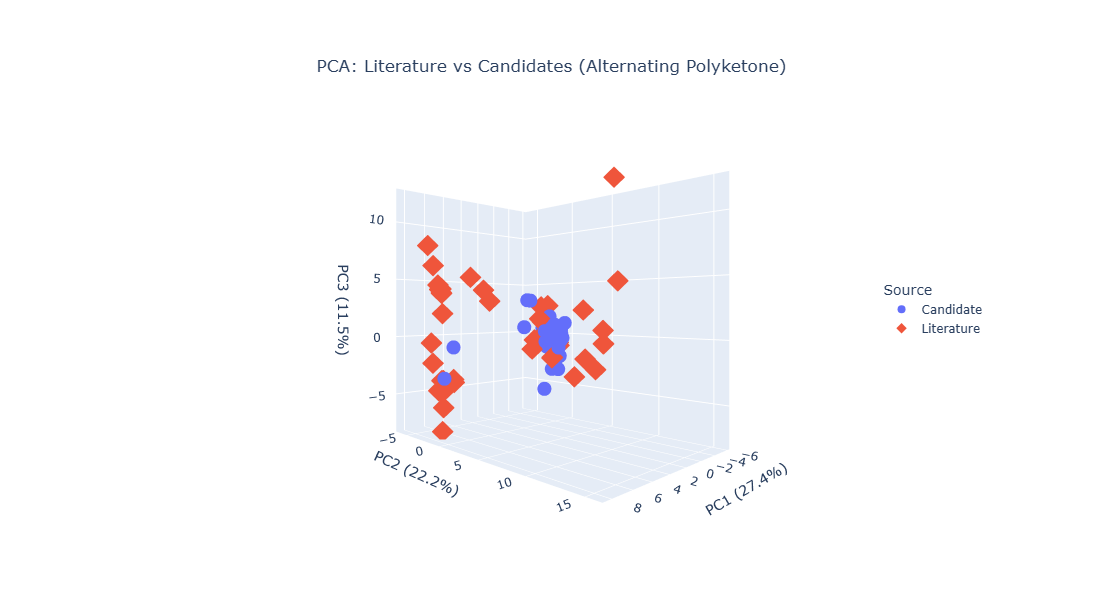

In [37]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import plotly.express as px

# === 1. Filter data ===
X = alt_merged_df.drop(columns=['Name', 'candidate_literature'])

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# === 2. PCA ===
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# === 3. Create DataFrame for plotting ===
alt_merged_df = alt_merged_df.reset_index(drop=True)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Source'] = alt_merged_df['candidate_literature']

# Create a new column: is_literature = True/False
pca_df['is_literature'] = pca_df['Source'].str.contains('literature', case=False, na=False)
pca_df['Source_Label'] = pca_df['is_literature'].map({True: 'Literature', False: 'Candidate'})

# === Plot with Plotly ===
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Source_Label',   # color by category
    symbol='Source_Label',  # different markers for literature vs candidate
    title="PCA: Literature vs Candidates (Alternating Polyketone)",
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        "PC3": f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    }
)

# === Style adjustments ===
fig.update_layout(
    width=800,
    height=600,
    legend=dict(title="Source", x=0.85, y=0.5, xanchor="left", yanchor="middle"),
    title=dict(x=0.5, y=0.9, xanchor="center", yanchor="top"),
    scene_camera=dict(eye=dict(x=1.5, y=1.5, z=0))  # starting camera angle
)

# === Show interactive ===
fig.show()

# === Save outputs ===
fig.write_image("alt_pca_3d_plot.png", scale=4)   # high-quality PNG
fig.write_html("alt_pca_3d_plot.html")            # interactive HTML


In [38]:
def simplify_name(name):
    match = re.search(r'ligand-(\d+)-(.*?)-int1', name)
    if match:
        return f"{match.group(1)}-{match.group(2)}"
    return name  # fallback if regex doesn't match

In [39]:
from scipy.spatial.distance import cdist

# Split into candidate and literature sets
candidates = pca_df[pca_df['Source_Label'] == 'Candidate'].copy()
literature = pca_df[pca_df['Source_Label'] == 'Literature'].copy()

# Attach 'Name' from original alt_merged_df
candidates['Name'] = alt_merged_df.loc[candidates.index, 'Name']

# Extract 3D coordinates
candidate_coords = candidates[['PC1', 'PC2', 'PC3']].values
literature_coords = literature[['PC1', 'PC2', 'PC3']].values

# Compute Euclidean distances in 3D space
dist_matrix = cdist(candidate_coords, literature_coords, metric='euclidean')

# Add minimum distance to each candidate
candidates['min_dist_to_lit'] = dist_matrix.min(axis=1)

# Rank candidates by proximity to literature
ranked_candidates = candidates.sort_values(by='min_dist_to_lit').reset_index(drop=True)

# Apply to your dataset
ranked_candidates['Simple_Name'] = ranked_candidates['Name'].apply(simplify_name)

# Optional: show top 10
print(ranked_candidates[['Simple_Name', 'PC1', 'PC2', 'PC3', 'min_dist_to_lit']].head(30))


# Save with new simplified title
ranked_candidates[['Simple_Name', 'PC1', 'PC2', 'PC3', 'min_dist_to_lit']] \
    .to_csv("alternating-polyketone-ranking-second-stage.csv", index=False)

print("CSV file saved as alternating-polyketone-ranking-second-stage.csv")



    Simple_Name       PC1       PC2       PC3  min_dist_to_lit
0      41-p-o-5  5.091029 -3.608099 -3.770843         0.000000
1    127-p-p-26 -3.549309 -0.287873  0.292952         0.353883
2   473-p-o-170  8.243119 -0.193039 -3.074696         0.506918
3     44-p-p-18 -3.962396 -0.434048 -0.903795         0.578572
4    481-p-p-36 -4.230259  0.499385 -0.526433         0.602023
5       2-p-p-1 -3.712770  0.010500 -0.874630         0.613380
6     48-p-p-22 -4.410714 -0.524412 -0.244235         0.657640
7    431-p-c-29 -3.198418 -0.052857  0.741385         0.694171
8    477-p-p-32 -4.149562 -0.717131 -1.569887         0.757891
9     47-p-p-21 -4.387945  0.563193 -0.323325         0.816132
10     22-p-c-9 -3.408935 -0.037687 -0.377868         0.885039
11    58-p-c-23 -3.719940 -0.515993  1.726263         0.887182
12     13-p-p-5 -4.700027  0.112037  0.047539         0.896443
13   126-p-p-25 -3.386422  0.375088 -1.114160         0.912955
14    35-p-p-14 -3.441307  0.575082 -1.231945         0

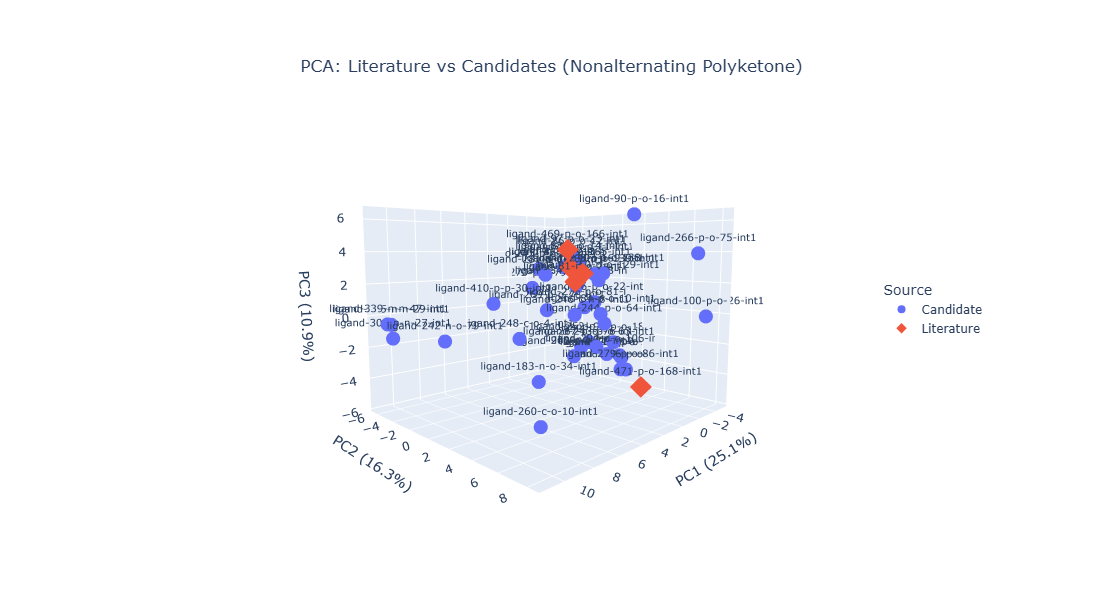

In [40]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import plotly.express as px

# === 1. Filter data ===
X = nonalt_merged_df.drop(columns=['Name', 'candidate_literature'])

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# === 2. PCA ===
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# === 3. Create DataFrame for plotting ===
nonalt_merged_df = nonalt_merged_df.reset_index(drop=True)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Name'] = nonalt_merged_df['Name'].values
pca_df['Source'] = nonalt_merged_df['candidate_literature']

# Create Source_Label
pca_df['is_literature'] = pca_df['Source'].str.contains('literature', case=False, na=False)
pca_df['Source_Label'] = pca_df['is_literature'].map({True: 'Literature', False: 'Candidate'})

# === Plot with Plotly (with labels) ===
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Source_Label',
    symbol='Source_Label',
    text='Name',   # 👈 add labels from Name column
    title='PCA: Literature vs Candidates (Nonalternating Polyketone)',
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        "PC3": f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    }
)

# make sure text is shown on top of markers
fig.update_traces(
    mode='markers+text',
    textposition='top center',
    textfont=dict(size=10)
)

# Style updates
fig.update_layout(
    width=800, 
    height=600,
    legend=dict(title="Source", x=0.85, y=0.5, xanchor="left", yanchor="middle"),
    title=dict(x=0.5, y=0.9, xanchor="center", yanchor="top"),
    scene_camera=dict(eye=dict(x=1.5, y=1.5, z=0.25))
)

fig.show()


# Save high-quality PNG
fig.write_image("nonalt_pca_3d_plot.png", scale=4)

# Save interactive HTML
fig.write_html("nonalt_pca_3d_plot.html")


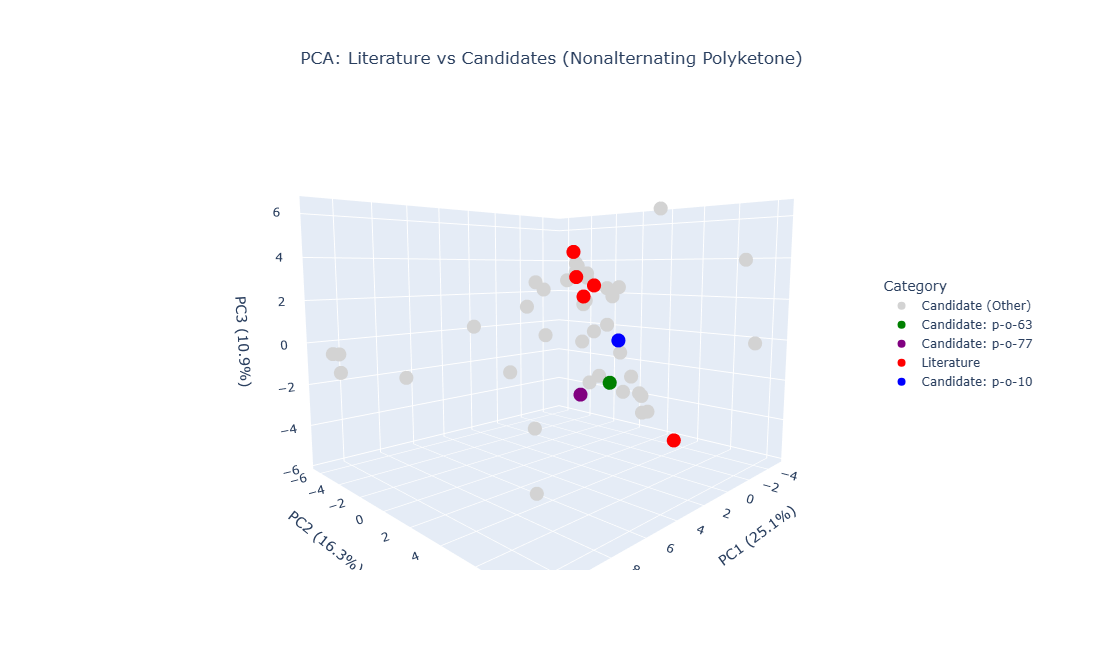

In [52]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import plotly.express as px

# === 1. Filter data ===
X = nonalt_merged_df.drop(columns=['Name', 'candidate_literature'])

# Standardize
X_scaled = StandardScaler().fit_transform(X)

# === 2. PCA ===
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# === 3. Create DataFrame for plotting ===
nonalt_merged_df = nonalt_merged_df.reset_index(drop=True)
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2', 'PC3'])
pca_df['Name'] = nonalt_merged_df['Name'].values
pca_df['Source'] = nonalt_merged_df['candidate_literature']

# Create Source_Label
pca_df['is_literature'] = pca_df['Source'].str.contains('literature', case=False, na=False)
pca_df['Source_Label'] = pca_df['is_literature'].map({True: 'Literature', False: 'Candidate'})

import re
import plotly.express as px

# === 4. Assign custom highlight categories ===
def classify_point(name, source):
    if isinstance(source, str) and "literature" in source.lower():
        return "Literature"
    elif re.search(r"\bp-o-10\b", name, re.IGNORECASE):   # match exactly "p-o-10"
        return "Candidate: p-o-10"
    elif re.search(r"\bp-o-63\b", name, re.IGNORECASE):   # exact "p-o-63"
        return "Candidate: p-o-63"
    elif re.search(r"\bp-o-77\b", name, re.IGNORECASE):   # exact "p-o-77"
        return "Candidate: p-o-77"
    else:
        return "Candidate (Other)"

pca_df['Category'] = pca_df.apply(lambda row: classify_point(row['Name'], row['Source']), axis=1)

# === 5. Plot with Plotly ===
fig = px.scatter_3d(
    pca_df,
    x='PC1', y='PC2', z='PC3',
    color='Category',          # 👈 custom color categories
    hover_name='Name',
    # text=pca_df.apply(lambda r: r['Name'] if "Candidate:" in r['Category'] else "", axis=1), # labels only for selected
    title='PCA: Literature vs Candidates (Nonalternating Polyketone)',
    labels={
        "PC1": f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
        "PC2": f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
        "PC3": f"PC3 ({pca.explained_variance_ratio_[2]*100:.1f}%)"
    }
)

# === Custom colors ===
custom_colors = {
    "Literature": "red",
    "Candidate: p-o-10": "blue",
    "Candidate: p-o-63": "green",
    "Candidate: p-o-77": "purple",
    "Candidate (Other)": "lightgray"
}

fig.update_traces(
    textposition='top center',
    textfont=dict(size=10)
)

fig.update_layout(
    width=900, height=650,
    legend=dict(title="Category", x=0.85, y=0.5, xanchor="left", yanchor="middle"),
    title=dict(x=0.5, y=0.92, xanchor="center", yanchor="top"),
    scene_camera=dict(eye=dict(x=1.5, y=1.5, z=0.25)),
    coloraxis=dict(colorscale=list(custom_colors.values()))
)

# Manually map the color sequence to match dict
fig.for_each_trace(
    lambda t: t.update(marker=dict(color=custom_colors.get(t.name, "gray")))
)

fig.show()

# Exports
fig.write_image("nonalt_pca_3d_plot.png", scale=4)
fig.write_html("nonalt_pca_3d_plot.html")
fig.write_image("nonalt_pca_3d_plot.pdf")            # vector for Illustrator

In [56]:
import plotly.express as px

pairs = [("PC1","PC2"), ("PC1","PC3"), ("PC2","PC3")]
figs = []
for x,y in pairs:
    f = px.scatter(
        pca_df, x=x, y=y,
        color="Category",
        hover_name="Name",
        labels={x: x, y: y}
    )
    # Custom colors (no borders on markers)
    custom_colors = {
        "Literature": "red",
        "Candidate: p-o-10": "blue",
        "Candidate: p-o-63": "green",
        "Candidate: p-o-77": "purple",
        "Candidate (Other)": "lightgray"
    }
    f.for_each_trace(
        lambda t: t.update(
            marker=dict(
                color=custom_colors.get(t.name, "gray"),
                size=8
            )
        )
    )
    
    # White background, no grid, black axes + legend box
    f.update_layout(
        plot_bgcolor="white",
        paper_bgcolor="white",
        xaxis=dict(showgrid=False, linecolor="black", mirror=True, ticks="outside"),
        yaxis=dict(showgrid=False, linecolor="black", mirror=True, ticks="outside"),
        legend=dict(
            bgcolor="white",          # legend box fill
            bordercolor="black",      # legend border
            borderwidth=1,            # thickness of legend border
            x=0.99, y=0.99,           # position (top right)
            xanchor="right", yanchor="top"
        )
    )
    
    figs.append(f)

# Export SVGs for Illustrator
figs[0].write_image("pca_PC1_PC2.svg")
figs[1].write_image("pca_PC1_PC3.svg")
figs[2].write_image("pca_PC2_PC3.svg")


In [41]:
from scipy.spatial.distance import cdist

# Split into candidate and literature sets
candidates = pca_df[pca_df['Source_Label'] == 'Candidate'].copy()
literature = pca_df[pca_df['Source_Label'] == 'Literature'].copy()

# Attach 'Name' from original nonalt_merged_df
candidates['Name'] = nonalt_merged_df.loc[candidates.index, 'Name']

# Extract 3D coordinates
candidate_coords = candidates[['PC1', 'PC2', 'PC3']].values
literature_coords = literature[['PC1', 'PC2', 'PC3']].values

# Compute Euclidean distances in 3D space
dist_matrix = cdist(candidate_coords, literature_coords, metric='euclidean')

# Add minimum distance to each candidate
candidates['min_dist_to_lit'] = dist_matrix.min(axis=1)

# Rank candidates by proximity to literature
ranked_candidates = candidates.sort_values(by='min_dist_to_lit').reset_index(drop=True)


# Apply to your dataset
ranked_candidates['Simple_Name'] = ranked_candidates['Name'].apply(simplify_name)

# Optional: show top 10
print(ranked_candidates[['Simple_Name', 'PC1', 'PC2', 'PC3', 'min_dist_to_lit']].head(30))


# Save with new simplified title
ranked_candidates[['Simple_Name', 'PC1', 'PC2', 'PC3', 'min_dist_to_lit']] \
    .to_csv("nonalternating-polyketone-ranking-second-stage.csv", index=False)

# # Select the relevant columns to save
# output_df = ranked_candidates[['Name', 'PC1', 'PC2', 'PC3', 'min_dist_to_lit']]

# # Save to CSV
# output_df.to_csv("nonalternating-polyketone-ranking-second-stage.csv", index=False)

print("CSV file saved as nonalternating-polyketone-ranking-second-stage.csv")


    Simple_Name        PC1       PC2       PC3  min_dist_to_lit
0     84-p-o-10   4.422716  6.116191  0.653339         2.355051
1     246-c-n-8   2.306496  2.281244  0.068724         4.023332
2    410-p-p-30   6.673715 -0.348632  0.900192         5.377479
3    260-c-o-10   6.619349  3.678515 -5.780788         6.090642
4    279-p-o-86  -1.257853  3.237838 -3.855196         7.055811
5     90-p-o-16  -1.518952  3.927228  6.406413         7.106254
6   407-p-o-138  -1.982991  1.050262  2.504819         7.483723
7   408-p-o-139  -1.880894  0.315506  2.438171         7.735041
8    242-n-o-79  10.348304 -0.035556 -0.892464         7.924891
9   350-p-o-129  -2.426092  0.259179  1.970421         8.290278
10   266-p-o-75  -3.600331  7.394241  3.914711         8.639590
11   100-p-o-26  -4.491054  7.601915 -0.160697         8.674778
12   244-p-o-64  -2.361413  0.902748 -1.099599         8.688333
13    96-p-o-22  -2.879145 -0.470841  0.308770         9.337195
14   243-p-o-63  -2.023592  0.467144 -2.